# Declaración responsable sobre autoría y uso ético de inteligencia artificial, otros recursos o ayuda externa

Con la entrega de esta tarea, declaro de manera responsable que
es el resultado de mi trabajo intelectual personal y creativo, y que ha sido elaborado de acuerdo con los principios éticos y las normas de integridad vigentes en la comunidad académica y, más
específicamente, en la [Universidad Complutense de Madrid](https://www.ucm.es/file/declaracion-responsable-sobre-autoria-y-uso-%C3%89tico-de-herramientas-de-ia).

Soy, pues, autor del material aquí incluido y, cuando no ha sido así y he tomado el material de
otra fuente, lo he citado o bien he declarado su procedencia de forma clara -incluidas, en su
caso, herramientas de inteligencia artificial-. Las ideas y aportaciones principales incluidas en este trabajo, y que acreditan la adquisición de competencias, son mías y no proceden de otras fuentes o han sido reescritas usando material de otras fuentes.

Antes de entregar esta tarea, asegúrate de que todo funcione como se espera:

1. Reinicia el kernel  
   *(En la barra de menú, selecciona **Kernel → Restart**)*  

2. Ejecuta todas las celdas  
   *(En la barra de menú, selecciona **Cell → Run All**)*  

3. Asegúrate de completar todos los lugares donde aparezca:  
   - `YOUR CODE HERE`  
   - `"YOUR ANSWER HERE"`
     
4. Debes borrar las instrucciones que pone `raise NotImplementedError()`

5. Así como tu **nombre** a continuación:

In [1]:
NOMBRE = "Carlos San Román Cazorla"

## Notas para la entrega

* Se deben rellenar todos los cuadernos sin cambiar el nombre.
* Se debe comprimir la carpeta en un fichero `.zip`, llamado `tarea_final.zip`. **Importante**: por favor, no se entreguen ficheros `.rar`.
* Subir el fichero comprimido al campus virtual.

# Agencia para el Empleo del ayuntamiento de Madrid. Perfiles de personas inscritas

En este trabajo vamos a trabajar con datos del portal de datos abiertos del ayuntamiento de Madrid. En particular usaremos datos de la [Agencia de empleo](https://datos.madrid.es/portal/site/egob/menuitem.c05c1f754a33a9fbe4b2e4b284f1a5a0/?vgnextoid=710e760a581a7610VgnVCM1000001d4a900aRCRD&vgnextchannel=374512b9ace9f310VgnVCM100000171f5a0aRCRD&vgnextfmt=default).

Citando la propia página:

<q>La Agencia para el Empleo de Madrid es la entidad encargada por el Ayuntamiento de Madrid para la gestión de políticas activas de empleo, al objeto de facilitar y potenciar la inserción laboral de las personas sin empleo de la Ciudad de Madrid.</q>

<q>La Agencia actúa como una plataforma multilateral en la que reúne a dos grupos distintos pero interdependientes, los trabajadores/as desempleados/as y las empresas.</q>

<q>Este conjunto de datos ofrece la relación de perfiles de personas inscritas en la Agencia para el Empleo para poder acceder a sus servicios. Se incluye, entre otros datos, el detalle de la fecha de inscripción, sexo, año de nacimiento, nacionalidad y el objetivo profesional en cada caso. </q>

Junto a este enunciado hay un fichero con formato CSV, `inscripciones.csv`, con los datos de las personas inscritas en lo que se lleva de año 2025. Es un fichero CSV cuyo separador es el `;` y los datos necesarios están marcados con `"`. Podemos visualizar las 5 primeras líneas ejecutando la siguiente casilla:

In [2]:
DATAFILE = 'inscritos.csv'
TESTDATAFILE = 'inscritos_test_sample.csv'
with open(DATAFILE, encoding='utf-8-sig') as f:
    for _ in range(5):
        print(f.readline(), end='')
    

FECHA_INSCRIPCION;GENERO_DESC;DISTRITO_COD;DISTRITO_DESC;EDAD;NACIONALIDAD_DESC;OBJETIVOPROFESIONAL1_COD;OBJETIVOPROFESIONAL1_DESC;OBJETIVOPROFESIONAL2_COD;OBJETIVOPROFESIONAL2_DESC;OBJETIVOPROFESIONAL3_COD;OBJETIVOPROFESIONAL3_DESC;FX_CARGA
"ene-24";"Hombre";10;" LATINA";34;"Español";"5833";"Conserjes de edificios";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"ene-20";"Hombre";10;" LATINA";40;"Extracomunitario";"5500";"Cajeros y taquilleros (excepto bancos)";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"nov-23";"Hombre";13;" PUENTE DE VALLECAS";24;"Extracomunitario";"3510";"Agentes y representantes comerciales";"5420";"Operadores de telemarketing";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"
"oct-23";"Hombre";17;" VILLAVERDE";19;"Extracomunitario";"9820";"Reponedores";"5220";"Vendedores en tiendas y almacenes";"960

Para comprobar la correcta definición de los tipos, necesitamos el módulo `pytest`, que se instala ejecutando la siguiente línea:

In [3]:
pip install pytest


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install pandas



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


En todo proyecto se ha de incluir la importación de librerías y la definición de constantes en su inicio.
Acompañando a este enunciado, dispones de un fichero llamado `testing.py` con funciones de prueba que realizan comprobaciones en tus funciones. También se debe cargar este fichero, y otros necesarios, como puedes ver en la siguiente celda.

También, el fichero es bastante grande, unos 30Mb. Para que sea más sencillo desarrollar el programa adjuntamos también un fichero de muestra con el mismo formato, pero con un tamaño más manejable para hacer pruebas: `inscritos_test_sample.csv`. Te aconsejamos que pruebes tus funciones con este fichero más pequeño antes de probar con el fichero más grande.

In [84]:
import pytest
import doctest
from typing import TypedDict
import locale
import os
import csv
import random
import doctest
import datetime
import numpy as np

import testing

# Las constantes que definas deben ir aquí detrás:

# Para la primera función, la muestra aleatoria, necesitamos generar un número aleatroio entre 0 y 1
# el cual es necesario inicializarlo como variable global para ya que sirve como argumento para la función.
# Al tratarse de una probabilidad, lo llamaremos con la variable p:
p = random.random()


En este enunciado encontrarás casillas parecidas a estas. Sirven para comprobar si las funciones que defines 
funcionan como se espera de ellas. Si dan algún tipo de error es que tienes algo que corregir. La casilla que tienes simplemente comprueba que los ficheros de datos están correctamente en su sitio. 

In [6]:
testing.test_datafile(DATAFILE, TESTDATAFILE)

OK. Los ficheros están en su sitio. Puedes continuar


## Muestreo aleatorio

Define una función llamada `gen_sample` que tenga como datos el nombre de un fichero (un `str`) y un `float` entre 0 y 1 que indica la probabilidad con que cada línea del fichero original va a ser seleccionada en el set de muestra. Para ello debes usar la función `random` del módulo `random`, que genera de forma aleatoria un número aleatorio de forma uniforme entre 0 y 1. El fichero de muestra generado debe nombrarse como el original, añadiendo un sufijo al nombre del tipo `_XX` antes de la extensión. `XX` es la probabilidad indicada, (el número que, multiplicado por 100, dará aproximadamente el porcentaje de líneas escogidas) con una precisión de 2 dígitos. Por ejemplo, si el fichero es `inscritos.csv` y la probabilidad 0.05 (eo sea, se seleccionarán aproximadamente el 5% de los datos pra la muestra), el fichero generado se debe llamar `inscritos_05.csv`.

El primer argumento de la función es el fichero a procesar y el segundo, el porcentaje.
La función debe comprobar que el argumento del porcentaje está entre 0 y 1.

La función debe ir leyendo el fichero. Para cada línea, se debe generar un número aleatorio. Si el número generado es inferior al porcentaje, esa línea se incluye en el fichero destino. 
Este método no garantiza un porcentaje exacto, pero sí proporciona una aproximación aceptable, teniendo en cuenta el gran tamaño del conjunto de datos de prueba.

La línea primera, del encabezado, se debe incluir en cualquier caso.

In [ ]:
def gen_sample(nombre_fichero: str, p: float )-> None:
    """
    Genera un fichero de test a partir de otro fichero de datos, tomando una muestra aleatoria de sus filas.
    El número de filas se determina por el parámetro `p`, que es un número entre 0 y 1 que representa el porcentaje
    de filas que se tomarán del fichero original.

    Parameters:
    ------------
        nombre_fichero: El nombre del fichero original del que se tomará la muestra.
        p: El porcentaje de filas que se tomarán del fichero original, representado como un número entre 0 y 1.

    Returns:
    ------------
        None. La función genera un nuevo fichero con el mismo formato que el original, pero con
        solo una muestra aleatoria de sus filas, y lo guarda con un nombre que incluye el porcentaje de filas tomadas.
    
    Example:
    ------------
        >>> gen_sample('inscritos.csv', 0.25)
    """

    # 1. Validación de la probabilidad
    if not (0 <= p <= 1):
        raise ValueError("La probabilidad debe estar entre 0 y 1.")

    # 2. Construcción del nuevo nombre de archivo

    # Separamos la ruta/nombre de la extensión 
    nombre_base, extension = os.path.splitext(nombre_fichero)

    # Formateamos el sufijo con dos dígitos (multiplicando por 100)
    sufijo = f"{int(p * 100):02d}"
    nombre_destino = f"{nombre_base}_{sufijo}{extension}"

    # Creamos una estructura try-except para manejar la posibilidad de que el archivo no exista
    try:
        with open(nombre_fichero, 'r', encoding='utf-8') as f_entrada, \
             open(nombre_destino, 'w', encoding='utf-8') as f_salida:
            
            # 3. Procesamos el encabezado (Por el enunciado, la primera línea siempre se incluye)
            encabezado = f_entrada.readline()
            if encabezado:
                f_salida.write(encabezado)
            
            # 4. Procesamos el resto de las líneas
            for linea in f_entrada:
                if random.random() < p:
                    f_salida.write(linea)

    except FileNotFoundError:
        pass   #Si el archivo no existe, simplemente no hacemos nada

In [8]:
# En esta casilla, puedes generar tus propias pruebas.


### Autocomprobación

In [9]:
def check_gen_sample_result():
    import os
    gen_sample(DATAFILE, 0.01)
    data01 = DATAFILE.replace('.csv', '_01.csv')
    with open(data01, encoding='utf-8-sig') as f:
        for _ in range(5):
            print(f.readline(), end='')
    ratio = os.path.getsize(data01) / os.path.getsize(DATAFILE) 
    print(f'\n ratio: {ratio:0.2f}')
check_gen_sample_result()

FECHA_INSCRIPCION;GENERO_DESC;DISTRITO_COD;DISTRITO_DESC;EDAD;NACIONALIDAD_DESC;OBJETIVOPROFESIONAL1_COD;OBJETIVOPROFESIONAL1_DESC;OBJETIVOPROFESIONAL2_COD;OBJETIVOPROFESIONAL2_DESC;OBJETIVOPROFESIONAL3_COD;OBJETIVOPROFESIONAL3_DESC;FX_CARGA
"jul-17";"Mujer";22;" OTRO MUNICIPIO";45;"Español";"5722";"Cuidadores de niños en domicilios";"9210";"Personal de limpieza de oficinas, hoteles y otros establecimientos similares";"9700";"Peones de las industrias manufactureras";"2025-08-07 00:11:57.897"
"nov-19";"Mujer";15;" CIUDAD LINEAL";42;"Español";"5120";"Camareros asalariados";"9210";"Personal de limpieza de oficinas, hoteles y otros establecimientos similares";"9700";"Peones de las industrias manufactureras";"2025-08-07 00:11:57.897"
"oct-17";"Mujer";15;" CIUDAD LINEAL";46;"Español";"9100";"Empleados domésticos";"9210";"Personal de limpieza de oficinas, hoteles y otros establecimientos similares";"9700";"Peones de las industrias manufactureras";"2025-08-07 00:11:57.897"
"may-21";"Mujer";22;

### La instrucción anterior da una salida similar a esta:

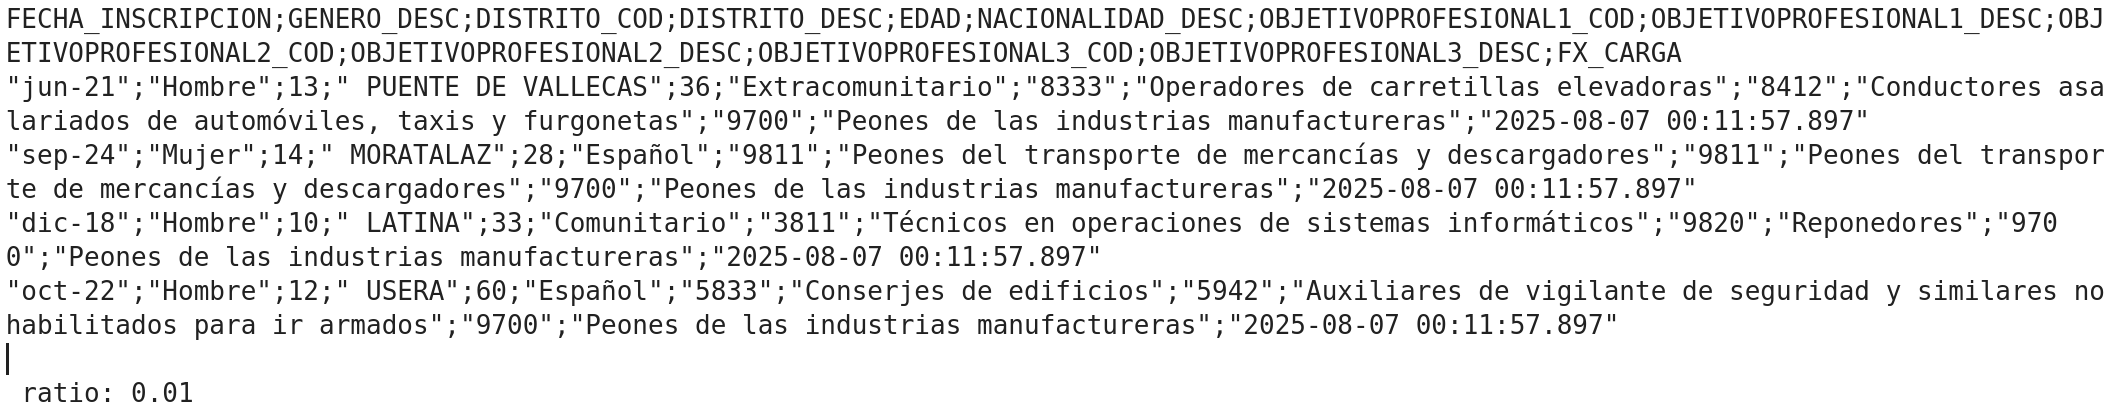

Puedes comprobar los doctests de tu función. 

In [10]:
doctest.run_docstring_examples(gen_sample, globals(), verbose=True)

Finding tests in NoName
Trying:
    gen_sample('inscritos.csv', 0.25)
Expecting nothing
ok


Comprueba la calidad del docstring

In [11]:
help(gen_sample)

Help on function gen_sample in module __main__:

gen_sample(nombre_fichero: str, p: float) -> None
    Genera un fichero de test a partir de otro fichero de datos, tomando una muestra aleatoria de sus filas.
    El número de filas se determina por el parámetro `p`, que es un número entre 0 y 1 que representa el porcentaje
    de filas que se tomarán del fichero original.

    Parameters:
    ------------
        nombre_fichero: El nombre del fichero original del que se tomará la muestra.
        p: El porcentaje de filas que se tomarán del fichero original, representado como un número entre 0 y 1.

    Returns:
    ------------
        None. La función genera un nuevo fichero con el mismo formato que el original, pero con
        solo una muestra aleatoria de sus filas, y lo guarda con un nombre que incluye el porcentaje de filas tomadas.

    Example:
    ------------
        >>> gen_sample('inscritos.csv', 0.25)



### Comprobación automática de tu código

In [12]:
testing.test_gen_sample(gen_sample)

test_gen_sample 0.01 1
Sample size 0.01 OK
test_gen_sample 0.02 1
Sample size 0.02 OK
test_gen_sample 0.05 1
Sample size 0.05 OK
test_gen_sample 0.1 1
Sample size 0.1 OK


In [13]:
testing.test_gen_sample_typehints(gen_sample)

check type hints OK


In [14]:
testing.test_docstring(gen_sample)

docstring OK


In [15]:
testing.test_doctests(gen_sample, globals())

doctests OK


# Lectura del fichero

Vamos a hacer una función que lea el fichero de datos y lo almacene en una variable para luego usarla para analizar datos.

Para ello vamos a ver cómo es la cabecera y la primera línea del fichero de datos.

In [16]:
with open(DATAFILE, encoding='utf-8-sig') as f:
    header = f.readline()
    print(header.strip())
    line = f.readline()
    print(line.strip())

FECHA_INSCRIPCION;GENERO_DESC;DISTRITO_COD;DISTRITO_DESC;EDAD;NACIONALIDAD_DESC;OBJETIVOPROFESIONAL1_COD;OBJETIVOPROFESIONAL1_DESC;OBJETIVOPROFESIONAL2_COD;OBJETIVOPROFESIONAL2_DESC;OBJETIVOPROFESIONAL3_COD;OBJETIVOPROFESIONAL3_DESC;FX_CARGA
"ene-24";"Hombre";10;" LATINA";34;"Español";"5833";"Conserjes de edificios";"5220";"Vendedores en tiendas y almacenes";"9602";"Peones de la construcción de edificios";"2025-08-07 00:11:57.897"


Vemos que los datos están separados por puntos y comas `;`, y algunos datos están entre comillas `"`. Por tanto, para leerlo deberemos usar la clase `DictReader` del módulo `csv` de forma adecuada. Al hacer la lectura con el `DictReader`, vamos a obtener un diccionario con el siguiente aspecto:

    {'DISTRITO_COD': '10',
     'DISTRITO_DESC': ' LATINA',
     'EDAD': '34',
     'FECHA_INSCRIPCION': 'ene-24',
     'FX_CARGA': '2025-08-07 00:11:57.897',
     'GENERO_DESC': 'Hombre',
     'NACIONALIDAD_DESC': 'Español',
     'OBJETIVOPROFESIONAL1_COD': '5833',
     'OBJETIVOPROFESIONAL1_DESC': 'Conserjes de edificios',
     'OBJETIVOPROFESIONAL2_COD': '5220',
     'OBJETIVOPROFESIONAL2_DESC': 'Vendedores en tiendas y almacenes',
     'OBJETIVOPROFESIONAL3_COD': '9602',
     'OBJETIVOPROFESIONAL3_DESC': 'Peones de la construcción de edificios'}

En este diccionario, todos los valores son cadenas de caracteres. Necesitaremos funciones para transformar los datos que no sean cadenas de caracteres en datos numéricos (`int`) o fechas (`datetime.datetime`). En cualquier caso, no podremos asumir que los datos sean correctos: pueden no estar consignados, o ser incorrectos.    

## Función str2int
Realizaremos una función `str2int` de forma que tome una cadena de caracteres y la transforme en el correspondiente entero. En caso de que el entero no esté o esté de forma incorrecta, la función debe devolver un 0.


In [ ]:
def str2int(cadena: str) -> int:
    """
    Convierte una cadena a entero. 
    Devuelve el entero si es posible, de lo contrario devuelve 0.

    Parameters:
    ------------
        cadena: La cadena que se desea convertir a entero.
        
    Returns:
    ------------
        int. El entero convertido si es posible, o 0 si no se puede convertir.
    
    Example:
    ------------
        >>> str2int('123')
        123
        >>> str2int('abc')
        0
    """
    try:
        # Intentamos la conversión directa
        return int(cadena)
    except (ValueError, TypeError):
        # ValueError: si la cadena tiene letras o símbolos no numéricos
        # TypeError: si el argumento no es una cadena 
        return 0

In [18]:
# En esta casilla, puedes generar tus propias pruebas.


### Autocomprobación


In [19]:
def check_str2int():
    n = str2int('1234')
    print(f"str2int 1: {n}")

    n = str2int('')
    print(f"str2int 2: {n}")

    n = str2int('wrong')
    print(f"str2int 3: {n}")

check_str2int()


str2int 1: 1234
str2int 2: 0
str2int 3: 0


Salida esperada:

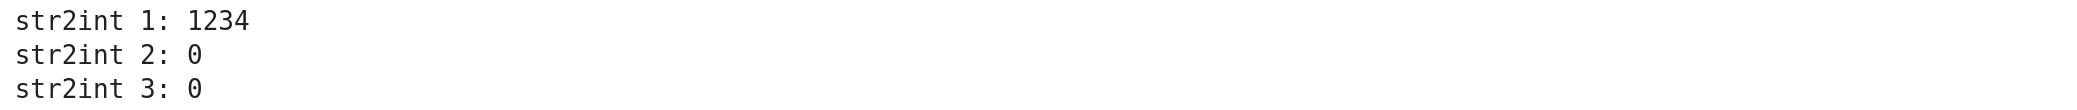

Puedes comprobar los doctests de tu función.

In [20]:
doctest.run_docstring_examples(str2int, globals(), verbose=True)

Finding tests in NoName
Trying:
    str2int('123')
Expecting:
    123
ok
Trying:
    str2int('abc')
Expecting:
    0
ok


Comprueba la calidad del docstring

In [21]:
help(str2int)

Help on function str2int in module __main__:

str2int(cadena: str) -> int
    Convierte una cadena a entero.
    Devuelve el entero si es posible, de lo contrario devuelve 0.

    Parameters:
    ------------
        cadena: La cadena que se desea convertir a entero.

    Returns:
    ------------
        El entero convertido si es posible, o 0 si no se puede convertir.

    Example:
    ------------
        >>> str2int('123')
        123
        >>> str2int('abc')
        0



In [22]:
### Comprobaciones automáticas

testing.test_str2int(str2int)

str2int OK


In [23]:
testing.test_docstring(str2int)

docstring OK


In [24]:
testing.test_str2int_typehints(str2int)

str2int type hints OK


In [25]:
testing.test_doctests(str2int, globals())

doctests OK


## Función `str2dt`

Vamos a realizar una función que transforme la fechas en el cadenas de caracteres como `'2025-08-07 00:11:57.897'` del campo `FX_CARGA`, a un objeto de clase `datetime` del módulo `datetime` con los datos correspondientes. 

**Indicación:** usa la función `strptime` de la clase `datetime`

Si el dato es vacío o incorrecto, la función debe devolver dato correspondiente a la fecha 1 de enero de 1970 a las 0 horas.

In [ ]:
def str2dt(date: str) -> datetime.datetime:
    """
    Convierte una cadena de caracteres con formato de fecha a un objeto datetime. 
    Devuelve el objeto datetime si es posible, de lo contrario devuelve 1 de enero de 1970 
    a las 0 horas (si el dato es vacío o incorrecto).
    
    Parameters:
    ------------
        date: La cadena con formato de fecha \'YYYY-MM-DD HH:MM:SS.NNN\' 
        que se desea convertir a objeto datetime.
        
    Returns:
    ------------
        datetime.datetime. El objeto datetime convertido si es posible, o 1 de enero de 1970 a las 0 horas.
    
    Example:
    ------------
        >>> str2dt('2023-01-01 12:00:00.000')
        datetime.datetime(2023, 1, 1, 12, 0)
        >>> str2dt('abc')
        datetime.datetime(1970, 1, 1, 0, 0)
    """
    try:
        # Intentamos la conversión directa
        return datetime.datetime.strptime(date, '%Y-%m-%d %H:%M:%S.%f')
    except (ValueError, TypeError):
        # ValueError: si la cadena tiene letras o símbolos no numéricos
        # TypeError: si el argumento no es una cadena 
        return datetime.datetime(1970, 1, 1, 0, 0, 0, 0)

### Autocomprobación


In [27]:
def check_str2dt():
    d = str2dt("2025-08-07 00:11:57.897")
    print(f"str2dt-1: {d}")
    d = str2dt("")
    print(f"str2dt-2: {d}")
    d = str2dt("wrong")
    print(f"str2dt-3: {d}")

check_str2dt()

str2dt-1: 2025-08-07 00:11:57.897000
str2dt-2: 1970-01-01 00:00:00
str2dt-3: 1970-01-01 00:00:00


Salida esperada:

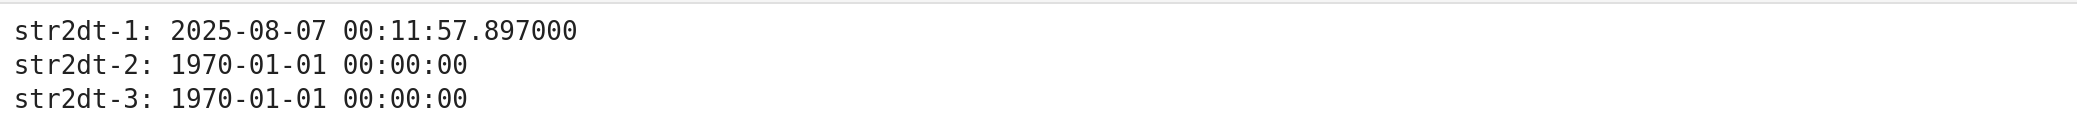

Puedes comprobar los doctests de tu función. 

In [28]:
doctest.run_docstring_examples(str2dt, globals(), verbose=True)

Finding tests in NoName
Trying:
    str2dt('2023-01-01 12:00:00.000')
Expecting:
    datetime.datetime(2023, 1, 1, 12, 0)
ok
Trying:
    str2dt('abc')
Expecting:
    datetime.datetime(1970, 1, 1, 0, 0)
ok


Comprueba la calidad del docstring

In [29]:
help(str2dt)

Help on function str2dt in module __main__:

str2dt(date: str) -> datetime.datetime
    Convierte una cadena de caracteres con formato de fecha a un objeto datetime.
    Devuelve el objeto datetime si es posible, de lo contrario devuelve 1 de enero de 1970
    a las 0 horas(si el dato es vacío o incorrecto).

    Parameters:
    ------------
        date: La cadena con formato de fecha 'YYYY-MM-DD HH:MM:SS.NNN'
        que se desea convertir a objeto datetime.

    Returns:
    ------------
        datetime.datetime. El objeto datetime convertido si es posible, o 1 de enero de 1970 a las 0 horas.

    Example:
    ------------
        >>> str2dt('2023-01-01 12:00:00.000')
        datetime.datetime(2023, 1, 1, 12, 0)
        >>> str2dt('abc')
        datetime.datetime(1970, 1, 1, 0, 0)



### Comprobación automática

In [30]:
testing.test_str2dt(str2dt)

str2dt OK
str2dt OK


In [31]:
testing.test_str2dt_typehints(str2dt)

str2dt type hints OK


In [32]:
testing.test_docstring(str2dt)

docstring OK


In [33]:
testing.test_doctests(str2dt, globals())

doctests OK


## Función `str2ym`

En el fichero de datos hay otra cadena de caracteres que se corresponde con una fecha. Es el campo `'FECHA_INSCRIPCION'` y los datos son de la forma `'ene-24'`. En teoría, la función `strptime` se podría usar poniendo la localización de forma adecuada. 

Lamentablemente, en la plataforma Windows el siguiente código no da el resultado esperado.

In [34]:
locale.setlocale(locale.LC_ALL, ("es_ES", "UTF-8"))
print(locale.getlocale())
s = 'ene-24'
try:
    dt = datetime.strptime(s, '%b-%y')
    print(dt)
except ValueError as e:
    print(f"Se ha producido un error al analizar la fecha: {e}")


('es_ES', 'UTF-8')


AttributeError: module 'datetime' has no attribute 'strptime'

Por tanto, no queda más remedio que hacer esta función a mano. Se pide una función llamada `str2ym` que analice un string como el pedido y devuelva la fecha adecuada.

In [36]:
def str2ym(date: str) -> datetime.datetime:
    """
    Convierte una cadena de caracteres con formato mes-año a un objeto datetime. 
    Devuelve el objeto datetime si es posible, de lo contrario devuelve 1 de enero de 1970 
    a las 0 horas (si el dato es vacío o incorrecto).
    
    Parameters:
    ------------
        date: La cadena con formato de fecha 'MM-YY' que se desea convertir a objeto datetime.
        
    Returns:
    ------------
        datetime.datetime. El objeto datetime convertido si es posible, o 1 de enero de 1970 
        si no es vacío o incorrecto.
    
    Example:
    ------------
        >>> str2ym('ene-24')
        datetime.datetime(2024, 1, 1, 0, 0)
        >>> str2ym('abc')
        datetime.datetime(1970, 1, 1, 0, 0)
    """

    if not date or len(date) != 6:
        return datetime.datetime(1970, 1, 1, 0, 0, 0)

    try:
        # Intentamos la conversión directa
        meses = {'ene': 1, 'feb': 2, 'mar': 3, 'abr': 4, 'may': 5, 'jun': 6,
                 'jul': 7, 'ago': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dic': 12}

        numero_mes = meses[date[:3]]
        anno = 2000 + int(date[4:6])
        return datetime.datetime(anno, numero_mes, 1, 0, 0)
    
    except (ValueError, TypeError):
        # ValueError: si la cadena tiene letras o símbolos no numéricos
        # TypeError: si el argumento no es una cadena 
        return datetime.datetime(1970, 1, 1, 0, 0)


### Autocomprobación


In [37]:
def check_str2ym():
    d = str2ym("ene-25")
    print(f"str2ym-1: {d}")
    d = str2ym("")
    print(f"str2ym-2: {d}")
    d = str2ym("wrong")
    print(f"str2ym-3: {d}")

check_str2ym()    

str2ym-1: 2025-01-01 00:00:00
str2ym-2: 1970-01-01 00:00:00
str2ym-3: 1970-01-01 00:00:00


Salida esperada:

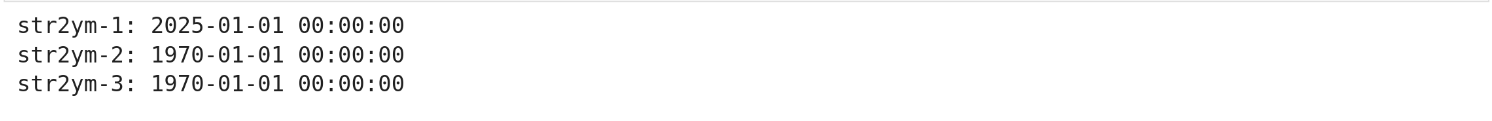

Puedes comprobar los doctests de tu función. 

In [38]:
doctest.run_docstring_examples(str2ym, globals(), verbose=True)

Finding tests in NoName
Trying:
    str2ym('ene-24')
Expecting:
    datetime.datetime(2024, 1, 1, 0, 0)
ok
Trying:
    str2ym('abc')
Expecting:
    datetime.datetime(1970, 1, 1, 0, 0)
ok


Comprueba tú mismo la calidad del docstring

In [39]:
help(str2ym)

Help on function str2ym in module __main__:

str2ym(date: str) -> datetime.datetime
    Convierte una cadena de caracteres con formato mes-año a un objeto datetime.
    Devuelve el objeto datetime si es posible, de lo contrario devuelve 1 de enero de 1970
    a las 0 horas (si el dato es vacío o incorrecto).

    Parameters:
    ------------
        date: La cadena con formato de fecha 'MM-YY' que se desea convertir a objeto datetime.

    Returns:
    ------------
        datetime.datetime. El objeto datetime convertido si es posible, o 1 de enero de 1970
        si no es vacío o incorrecto.

    Example:
    ------------
        >>> str2ym('ene-24')
        datetime.datetime(2024, 1, 1, 0, 0)
        >>> str2ym('abc')
        datetime.datetime(1970, 1, 1, 0, 0)



### Comprobación automática

In [40]:
testing.test_str2ym(str2ym)

Tests str2ym OK


In [41]:
testing.test_str2ym_typehints(str2ym)

str2ym type hints OK


In [42]:
testing.test_docstring(str2ym)

docstring OK


In [43]:
testing.test_doctests(str2ym, globals())

doctests OK


# Diccionario de datos

Para almacenar un fichero vamos a usar un diccionario. Las claves serán cada uno de los campos del fichero que estamos tratando.
Los valores serán listas de valores, cada campo tiene una lista asociada a cada valor del fichero. Así, los datos de la primera línea estarán en la posición 0 de las correspondientes listas. Los datos de la segunda línea en la posición 1 y así sucesivamente.

Es un diccionario con claves fijas. Así nuestro diccionario se define de la siguiente forma


In [44]:
class EmploymentData(TypedDict):
    FECHA_INSCRIPCION: list[datetime]
    GENERO_DESC: list[str]
    DISTRITO_COD: list[int]
    DISTRITO_DESC: list[str]
    EDAD: list[int]
    NACIONALIDAD_DESC: list[str]
    OBJETIVOPROFESIONAL1_COD: list[int]
    OBJETIVOPROFESIONAL1_DESC: list[str]
    OBJETIVOPROFESIONAL2_COD: list[int]
    OBJETIVOPROFESIONAL2_DESC: list[str]
    OBJETIVOPROFESIONAL3_COD: list[int]
    OBJETIVOPROFESIONAL3_DESC: list[str]
    FX_CARGA: list[datetime]


Un objeto sin datos será:

In [45]:
emptydata: EmploymentData = \
  {"FECHA_INSCRIPCION": [],
   "GENERO_DESC": [],
   "DISTRITO_COD": [],
   "DISTRITO_DESC": [],
   "EDAD": [],
   "NACIONALIDAD_DESC": [],
   "OBJETIVOPROFESIONAL1_COD": [],
   "OBJETIVOPROFESIONAL1_DESC": [],
   "OBJETIVOPROFESIONAL2_COD": [],
   "OBJETIVOPROFESIONAL2_DESC": [],
   "OBJETIVOPROFESIONAL3_COD": [],
   "OBJETIVOPROFESIONAL3_DESC": [],
   "FX_CARGA": []
  }


## Función add_row

Es necesario definir una función que tome un diccionario como el que devuelve un `DictReader` y los añade a un diccionario
de tipo `EmploymentData`. Recordemos que los diccionarios que devuelve un `DictReader` es un diccionario como el siguiente:

    {'DISTRITO_COD': '10',
     'DISTRITO_DESC': ' LATINA',
     'EDAD': '34',
     'FECHA_INSCRIPCION': 'ene-24',
     'FX_CARGA': '2025-08-07 00:11:57.897',
     'GENERO_DESC': 'Hombre',
     'NACIONALIDAD_DESC': 'Español',
     'OBJETIVOPROFESIONAL1_COD': '5833',
     'OBJETIVOPROFESIONAL1_DESC': 'Conserjes de edificios',
     'OBJETIVOPROFESIONAL2_COD': '5220',
     'OBJETIVOPROFESIONAL2_DESC': 'Vendedores en tiendas y almacenes',
     'OBJETIVOPROFESIONAL3_COD': '9602',
     'OBJETIVOPROFESIONAL3_DESC': 'Peones de la construcción de edificios'}

Su tipo es `dict[str, str]`

Realiza una función `add_row(ed: EmploymentData, row: dict[str, str])` que añada `row` en el diccionario `ed`.

In [46]:
def add_row(data: EmploymentData, row: dict[str, str]) -> None:
    """
    Añade la fila row al diccionario data de la clase EmploymentDataa
    
    Parameters:
    ------------
        data: Es el diccionario que nos sirve de base de datos
        row: Es el nuevo registro que queremos añadir al diccionario datsa
        
    Returns:
    ------------
        None. No devuelve ningún resultado, simplemente añade el registro ow a data.

    Example:
    --------
    >>> from datetime import datetime
    >>> data: EmploymentData = {"FECHA_INSCRIPCION": [], "GENERO_DESC": [], "DISTRITO_COD": [], "DISTRITO_DESC": [], "EDAD": [], "NACIONALIDAD_DESC": [], "OBJETIVOPROFESIONAL1_COD": [], "OBJETIVOPROFESIONAL1_DESC": [], "OBJETIVOPROFESIONAL2_COD": [], "OBJETIVOPROFESIONAL2_DESC": [], "OBJETIVOPROFESIONAL3_COD": [], "OBJETIVOPROFESIONAL3_DESC": [], "FX_CARGA": []}
    >>> row = {'DISTRITO_COD': '10', 'DISTRITO_DESC': ' LATINA', 'EDAD': '34', 'FECHA_INSCRIPCION': 'ene-24', 'FX_CARGA': '2025-08-07 00:11:57.897', 'GENERO_DESC': 'Hombre', 'NACIONALIDAD_DESC': 'Español', 'OBJETIVOPROFESIONAL1_COD': '5833', 'OBJETIVOPROFESIONAL1_DESC': 'Conserjes de edificios', 'OBJETIVOPROFESIONAL2_COD': '5220', 'OBJETIVOPROFESIONAL2_DESC': 'Vendedores en tiendas y almacenes', 'OBJETIVOPROFESIONAL3_COD': '9602', 'OBJETIVOPROFESIONAL3_DESC': 'Peones de la construcción de edificios'}
    >>> add_row(data, row)
    >>> data['FECHA_INSCRIPCION']
    [datetime.datetime(2024, 1, 1, 0, 0)]
    >>> data['GENERO_DESC']
    ['Hombre']
    >>> data['DISTRITO_COD']
    [10]
    >>> data['DISTRITO_DESC']
    ['LATINA']
    >>> data['EDAD']
    [34]
    >>> data['NACIONALIDAD_DESC']
    ['Español']
    >>> data['OBJETIVOPROFESIONAL1_COD']
    [5833]
    >>> data['OBJETIVOPROFESIONAL1_DESC']
    ['Conserjes de edificios']
    >>> data['OBJETIVOPROFESIONAL2_COD']
    [5220]
    >>> data['OBJETIVOPROFESIONAL2_DESC']
    ['Vendedores en tiendas y almacenes']
    >>> data['OBJETIVOPROFESIONAL3_COD']
    [9602]
    >>> data['OBJETIVOPROFESIONAL3_DESC']
    ['Peones de la construcción de edificios']
    >>> data['FX_CARGA']
    [datetime.datetime(2025, 8, 7, 0, 11, 57, 897000)]
    """

    # Definimos los campos que deben ser convertidos a su tipo correspondiente
    INT_FIELDS = {"DISTRITO_COD", "EDAD", "OBJETIVOPROFESIONAL1_COD", "OBJETIVOPROFESIONAL2_COD", "OBJETIVOPROFESIONAL3_COD"}
    YM_FIELDS = {"FECHA_INSCRIPCION"}
    DT_FIELDS = {"FX_CARGA"}

    # Recorremos cada clave-valor en la fila y aplicamos la conversión correspondiente según el tipo de campo
    for clave, valor in row.items():
        valor_limpio = valor.strip()
        if clave in INT_FIELDS:
            data[clave].append(int(valor_limpio) if valor_limpio else 0)
        elif clave in YM_FIELDS:
            data[clave].append(str2ym(valor_limpio))
        elif clave in DT_FIELDS:
            data[clave].append(str2dt(valor_limpio))
        else:
            data[clave].append(valor_limpio)


### Autocomprobación

In [47]:
def check_add_row():
    data: EmploymentData = \
         {"FECHA_INSCRIPCION": [],
           "GENERO_DESC": [],
           "DISTRITO_COD": [],
           "DISTRITO_DESC": [],
           "EDAD": [],
           "NACIONALIDAD_DESC": [],
           "OBJETIVOPROFESIONAL1_COD": [],
           "OBJETIVOPROFESIONAL1_DESC": [],
           "OBJETIVOPROFESIONAL2_COD": [],
           "OBJETIVOPROFESIONAL2_DESC": [],
           "OBJETIVOPROFESIONAL3_COD": [],
           "OBJETIVOPROFESIONAL3_DESC": [],
           "FX_CARGA": []
          }
    row =     {'DISTRITO_COD': '10',
     'DISTRITO_DESC': ' LATINA',
     'EDAD': '34',
     'FECHA_INSCRIPCION': 'ene-24',
     'FX_CARGA': '2025-08-07 00:11:57.897',
     'GENERO_DESC': 'Hombre',
     'NACIONALIDAD_DESC': 'Español',
     'OBJETIVOPROFESIONAL1_COD': '5833',
     'OBJETIVOPROFESIONAL1_DESC': 'Conserjes de edificios',
     'OBJETIVOPROFESIONAL2_COD': '5220',
     'OBJETIVOPROFESIONAL2_DESC': 'Vendedores en tiendas y almacenes',
     'OBJETIVOPROFESIONAL3_COD': '9602',
     'OBJETIVOPROFESIONAL3_DESC': 'Peones de la construcción de edificios'}
    add_row(data, row)
    for k, v in data.items():
        print(f"add_data-2: {k}:{v}")

    row =     {'DISTRITO_COD': '',
     'DISTRITO_DESC': ' LATINA',
     'EDAD': '',
     'FECHA_INSCRIPCION': '',
     'FX_CARGA': '',
     'GENERO_DESC': '',
     'NACIONALIDAD_DESC': '',
     'OBJETIVOPROFESIONAL1_COD': '',
     'OBJETIVOPROFESIONAL1_DESC': '',
     'OBJETIVOPROFESIONAL2_COD': '',
     'OBJETIVOPROFESIONAL2_DESC': '',
     'OBJETIVOPROFESIONAL3_COD': '',
     'OBJETIVOPROFESIONAL3_DESC': ''
              }
    add_row(data, row)
    for k, v in data.items():
        print(f"add_data-2: {k}:{v}")
    
check_add_row()

add_data-2: FECHA_INSCRIPCION:[datetime.datetime(2024, 1, 1, 0, 0)]
add_data-2: GENERO_DESC:['Hombre']
add_data-2: DISTRITO_COD:[10]
add_data-2: DISTRITO_DESC:['LATINA']
add_data-2: EDAD:[34]
add_data-2: NACIONALIDAD_DESC:['Español']
add_data-2: OBJETIVOPROFESIONAL1_COD:[5833]
add_data-2: OBJETIVOPROFESIONAL1_DESC:['Conserjes de edificios']
add_data-2: OBJETIVOPROFESIONAL2_COD:[5220]
add_data-2: OBJETIVOPROFESIONAL2_DESC:['Vendedores en tiendas y almacenes']
add_data-2: OBJETIVOPROFESIONAL3_COD:[9602]
add_data-2: OBJETIVOPROFESIONAL3_DESC:['Peones de la construcción de edificios']
add_data-2: FX_CARGA:[datetime.datetime(2025, 8, 7, 0, 11, 57, 897000)]
add_data-2: FECHA_INSCRIPCION:[datetime.datetime(2024, 1, 1, 0, 0), datetime.datetime(1970, 1, 1, 0, 0)]
add_data-2: GENERO_DESC:['Hombre', '']
add_data-2: DISTRITO_COD:[10, 0]
add_data-2: DISTRITO_DESC:['LATINA', 'LATINA']
add_data-2: EDAD:[34, 0]
add_data-2: NACIONALIDAD_DESC:['Español', '']
add_data-2: OBJETIVOPROFESIONAL1_COD:[5833, 0

Salida esperada:

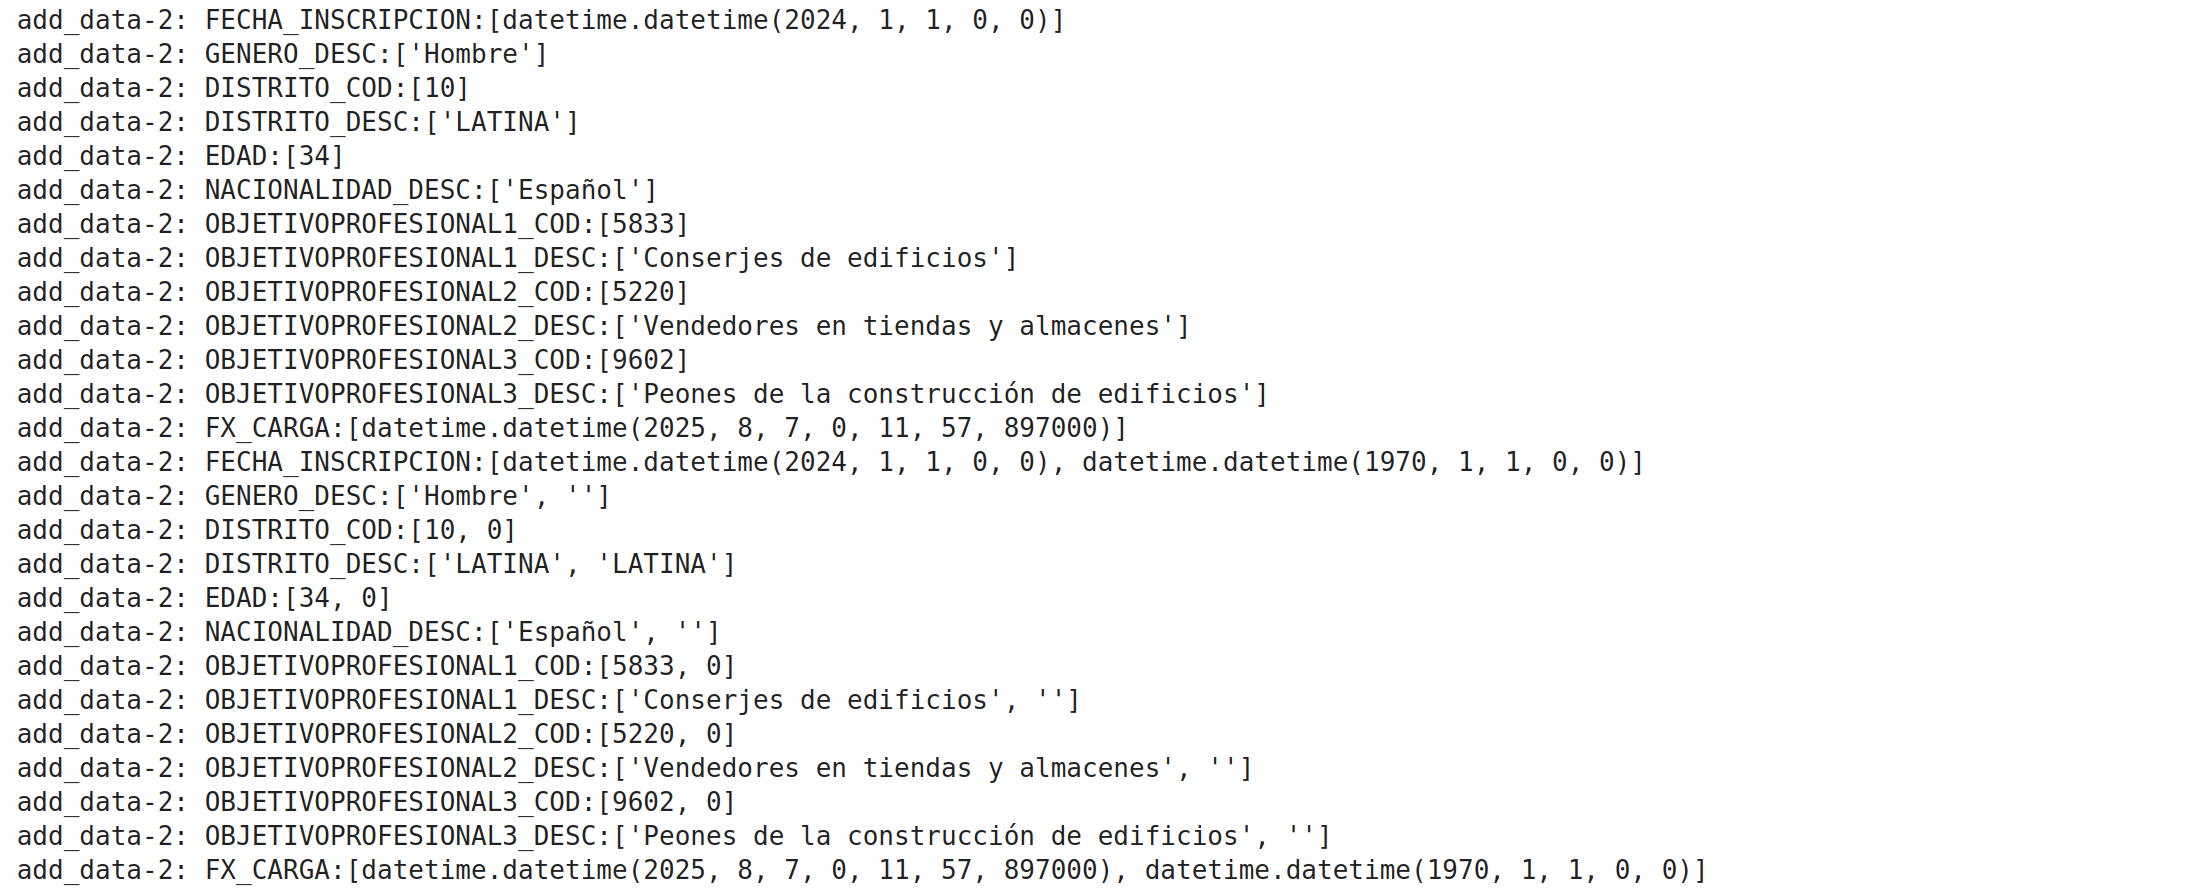

Puedes comprobar los doctests de tu función. 

In [48]:
doctest.run_docstring_examples(add_row, globals(), verbose=True)

Finding tests in NoName
Trying:
    from datetime import datetime
Expecting nothing
ok
Trying:
    data: EmploymentData = {"FECHA_INSCRIPCION": [], "GENERO_DESC": [], "DISTRITO_COD": [], "DISTRITO_DESC": [], "EDAD": [], "NACIONALIDAD_DESC": [], "OBJETIVOPROFESIONAL1_COD": [], "OBJETIVOPROFESIONAL1_DESC": [], "OBJETIVOPROFESIONAL2_COD": [], "OBJETIVOPROFESIONAL2_DESC": [], "OBJETIVOPROFESIONAL3_COD": [], "OBJETIVOPROFESIONAL3_DESC": [], "FX_CARGA": []}
Expecting nothing
ok
Trying:
    row = {'DISTRITO_COD': '10', 'DISTRITO_DESC': ' LATINA', 'EDAD': '34', 'FECHA_INSCRIPCION': 'ene-24', 'FX_CARGA': '2025-08-07 00:11:57.897', 'GENERO_DESC': 'Hombre', 'NACIONALIDAD_DESC': 'Español', 'OBJETIVOPROFESIONAL1_COD': '5833', 'OBJETIVOPROFESIONAL1_DESC': 'Conserjes de edificios', 'OBJETIVOPROFESIONAL2_COD': '5220', 'OBJETIVOPROFESIONAL2_DESC': 'Vendedores en tiendas y almacenes', 'OBJETIVOPROFESIONAL3_COD': '9602', 'OBJETIVOPROFESIONAL3_DESC': 'Peones de la construcción de edificios'}
Expecting not

Comprueba la calidad del docstring

In [49]:
help(add_row)

Help on function add_row in module __main__:

add_row(data: EmploymentData, row: dict[str, str]) -> None
    Añade la fila row al diccionario data de la clase EmploymentDataa

    Parameters:
    ------------
        data: Es el diccionario que nos sirve de base de datos
        row: Es el nuevo registro que queremos añadir al diccionario datsa

    Returns:
    ------------
        None. No devuelve ningún resultado, simplemente añade el registro ow a data.

    Example:
    --------
    >>> from datetime import datetime
    >>> data: EmploymentData = {"FECHA_INSCRIPCION": [], "GENERO_DESC": [], "DISTRITO_COD": [], "DISTRITO_DESC": [], "EDAD": [], "NACIONALIDAD_DESC": [], "OBJETIVOPROFESIONAL1_COD": [], "OBJETIVOPROFESIONAL1_DESC": [], "OBJETIVOPROFESIONAL2_COD": [], "OBJETIVOPROFESIONAL2_DESC": [], "OBJETIVOPROFESIONAL3_COD": [], "OBJETIVOPROFESIONAL3_DESC": [], "FX_CARGA": []}
    >>> row = {'DISTRITO_COD': '10', 'DISTRITO_DESC': ' LATINA', 'EDAD': '34', 'FECHA_INSCRIPCION': 'ene-24

### Comprobación automática

In [50]:
testing.test_add_row(add_row)

add_row OK
add_row with missing values OK


In [51]:
testing.test_add_row_typehints(add_row)

add_row type hints OK


In [52]:
testing.test_docstring(add_row)

docstring OK


In [53]:
testing.test_doctests(add_row, globals())

doctests OK


## Función `load_employment`

Debes realizar una función que lea un fichero de datos de empleo y devuelva un diccionario `EmploymentData`. 


In [54]:
def load_employment(filepath: str) -> EmploymentData:
    """
    Lee un fichero CSV de datos de empleo y devuelve un diccionario EmploymentData.

    El fichero debe tener separador ';' y los valores pueden estar entre comillas.

    Parameters:
    -----------
    filepath : Ruta al fichero CSV de empleo.

    Returns:
    --------
    EmploymentData: Diccionario con los datos de empleo leídos del fichero.

    Example:
    --------
    >>> data = load_employment(TESTDATAFILE)

    """
    # Inicializamos el diccionario con listas vacías para cada campo
    data = {
        "FECHA_INSCRIPCION": [],
        "GENERO_DESC": [],
        "DISTRITO_COD": [],
        "DISTRITO_DESC": [],
        "EDAD": [],
        "NACIONALIDAD_DESC": [],
        "OBJETIVOPROFESIONAL1_COD": [],
        "OBJETIVOPROFESIONAL1_DESC": [],
        "OBJETIVOPROFESIONAL2_COD": [],
        "OBJETIVOPROFESIONAL2_DESC": [],
        "OBJETIVOPROFESIONAL3_COD": [],
        "OBJETIVOPROFESIONAL3_DESC": [],
        "FX_CARGA": [],
    }

    with open(filepath, encoding="utf-8-sig") as f:
        reader = csv.DictReader(f, delimiter=';', quotechar='"')
        for row in reader:
            add_row(data, row)

    return data

### Autocomprobación

In [55]:
def check_load_employment():
    ed = load_employment(TESTDATAFILE)
    # ed = load_employment(DATAFILE)
    print(f"load_employment-1: {len(ed['FECHA_INSCRIPCION'])}")
    print(f"load_employment-2: {len(ed['EDAD'])}")
    print(f"load_employment-3: {ed['EDAD'][7]}")
    print(f"load_employment-4: {len([d for d in ed['DISTRITO_COD'] if d==1])}")
    print(f"load_employment-5: {len([d for d in ed['FECHA_INSCRIPCION'] if d.month==9] )}")
        
check_load_employment()

load_employment-1: 1508
load_employment-2: 1508
load_employment-3: 50
load_employment-4: 48
load_employment-5: 100


Salida esperada:

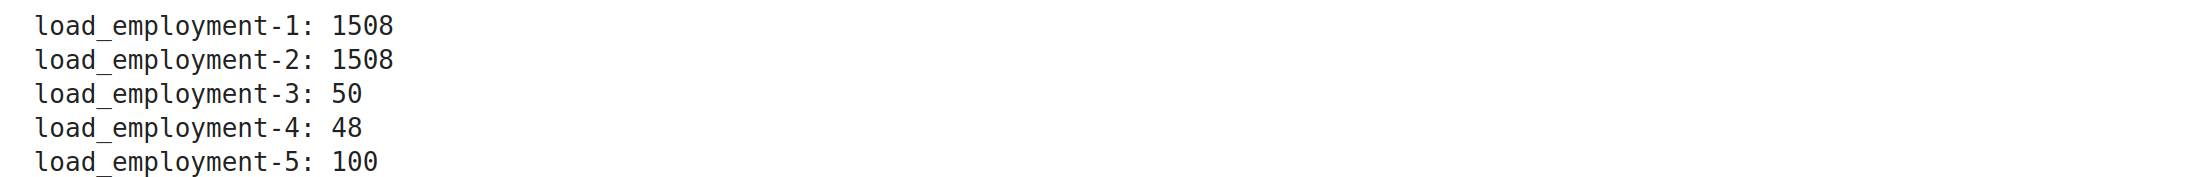

Comprueba la calidad del docstring

In [56]:
help(load_employment)

Help on function load_employment in module __main__:

load_employment(filepath: str) -> EmploymentData
    Lee un fichero CSV de datos de empleo y devuelve un diccionario EmploymentData.

    El fichero debe tener separador ';' y los valores pueden estar entre comillas.

    Parameters:
    -----------
    filepath : Ruta al fichero CSV de empleo.

    Returns:
    --------
    EmploymentData: Diccionario con los datos de empleo leídos del fichero.

    Example:
    --------
    >>> data = load_employment(TESTDATAFILE)



Puedes comprobar los doctests de tu función. 

In [57]:
doctest.run_docstring_examples(load_employment, globals(), verbose=True)

Finding tests in NoName
Trying:
    data = load_employment(TESTDATAFILE)
Expecting nothing
ok


### Comprobación automática

In [58]:
testing.test_load_employment(load_employment)

load_employment OK


In [59]:
testing.test_load_employment_typehints(load_employment)

test: {"<class 'str'>", "<class '__main__.EmploymentData'>"}
load_employment type hints OK


In [60]:
testing.test_docstring(load_employment)

docstring OK


In [61]:
testing.test_doctests(load_employment, globals())

doctests OK


# Extracción de información

En este apartado queremos sacar cierta información sobre los registros de empleo. 

Para ello vamos a guardar en una variable todos los registros de empleo

In [62]:
global employment_data
employment_data = load_employment('inscritos.csv')
employment_test_data = load_employment('inscritos_test_sample.csv')

## Función `people_by_district`

Esta función debe devolver una lista ordenada de tuplas. El primer elemento de cada tupa es el nombre del distrito y el segundo es el número de personas inscritas en el distrito. La lista está ordenada de forma descendente con respecto al número de personas inscritas.

In [64]:
def people_by_district(data: EmploymentData) -> list[tuple[str, int]]:
    """
    Devuelve una lista ordenada de tuplas (distrito, número de personas)
    en orden descendente por número de inscritos.

    Parameters:
    -----------
    data : EmploymentData
        Diccionario con los datos de empleo.

    Returns:
    --------
    list[tuple[str, int]]. Lista de tuplas (nombre_distrito, num_personas) ordenada de forma
        descendente por número de personas.

    Example:
    --------
    >>> people_by_district(employment_test_data)
    [('OTRO MUNICIPIO', 268), ('PUENTE DE VALLECAS', 141), ('CARABANCHEL', 124), ('LATINA', 123), ('VILLAVERDE', 94), ('CIUDAD LINEAL', 90), ('VILLA DE VALLECAS', 73), ('USERA', 71), ('TETUÁN', 71), ('VICÁLVARO', 54), ('FUENCARRAL-EL PARDO', 50), ('CENTRO', 48), ('ARGANZUELA', 46), ('HORTALEZA', 45), ('MORATALAZ', 41), ('SAN BLAS - CANILLEJAS', 41), ('CHAMBERÍ', 26), ('SALAMANCA', 25), ('RETIRO', 23), ('CHAMARTÍN', 21), ('MONCLOA-ARAVACA', 18), ('BARAJAS', 15)]
    """
    # 1. Contamos el número de personas por distrito
    conteo = {}
    for distrito in data['DISTRITO_DESC']:
        conteo[distrito] = conteo.get(distrito, 0) + 1

    # 2. Ordenamos el diccionario por número de personas en orden descendente
    sorted_dict = sorted(conteo.items(), key=lambda t: t[1], reverse=True)
    return [(distrito, count) for distrito, count in sorted_dict]

In [65]:
# Casilla para probar


### Autocomprobación

In [66]:
def check_people_by_district():
    global employment_data

    for district, people in people_by_district(employment_data):
        print(f'{district:.<25s}{people:>6d}')

check_people_by_district()    

OTRO MUNICIPIO........... 23768
PUENTE DE VALLECAS....... 15356
CARABANCHEL.............. 13022
LATINA................... 10251
VILLAVERDE...............  9995
CIUDAD LINEAL............  7897
USERA....................  7560
TETUÁN...................  7433
SAN BLAS - CANILLEJAS....  6059
VICÁLVARO................  5678
VILLA DE VALLECAS........  5510
ARGANZUELA...............  5460
CENTRO...................  5094
FUENCARRAL-EL PARDO......  4691
HORTALEZA................  4534
MORATALAZ................  3754
RETIRO...................  2770
CHAMBERÍ.................  2498
CHAMARTÍN................  2255
BARAJAS..................  2255
SALAMANCA................  2247
MONCLOA-ARAVACA..........  2050


Salida esperada:

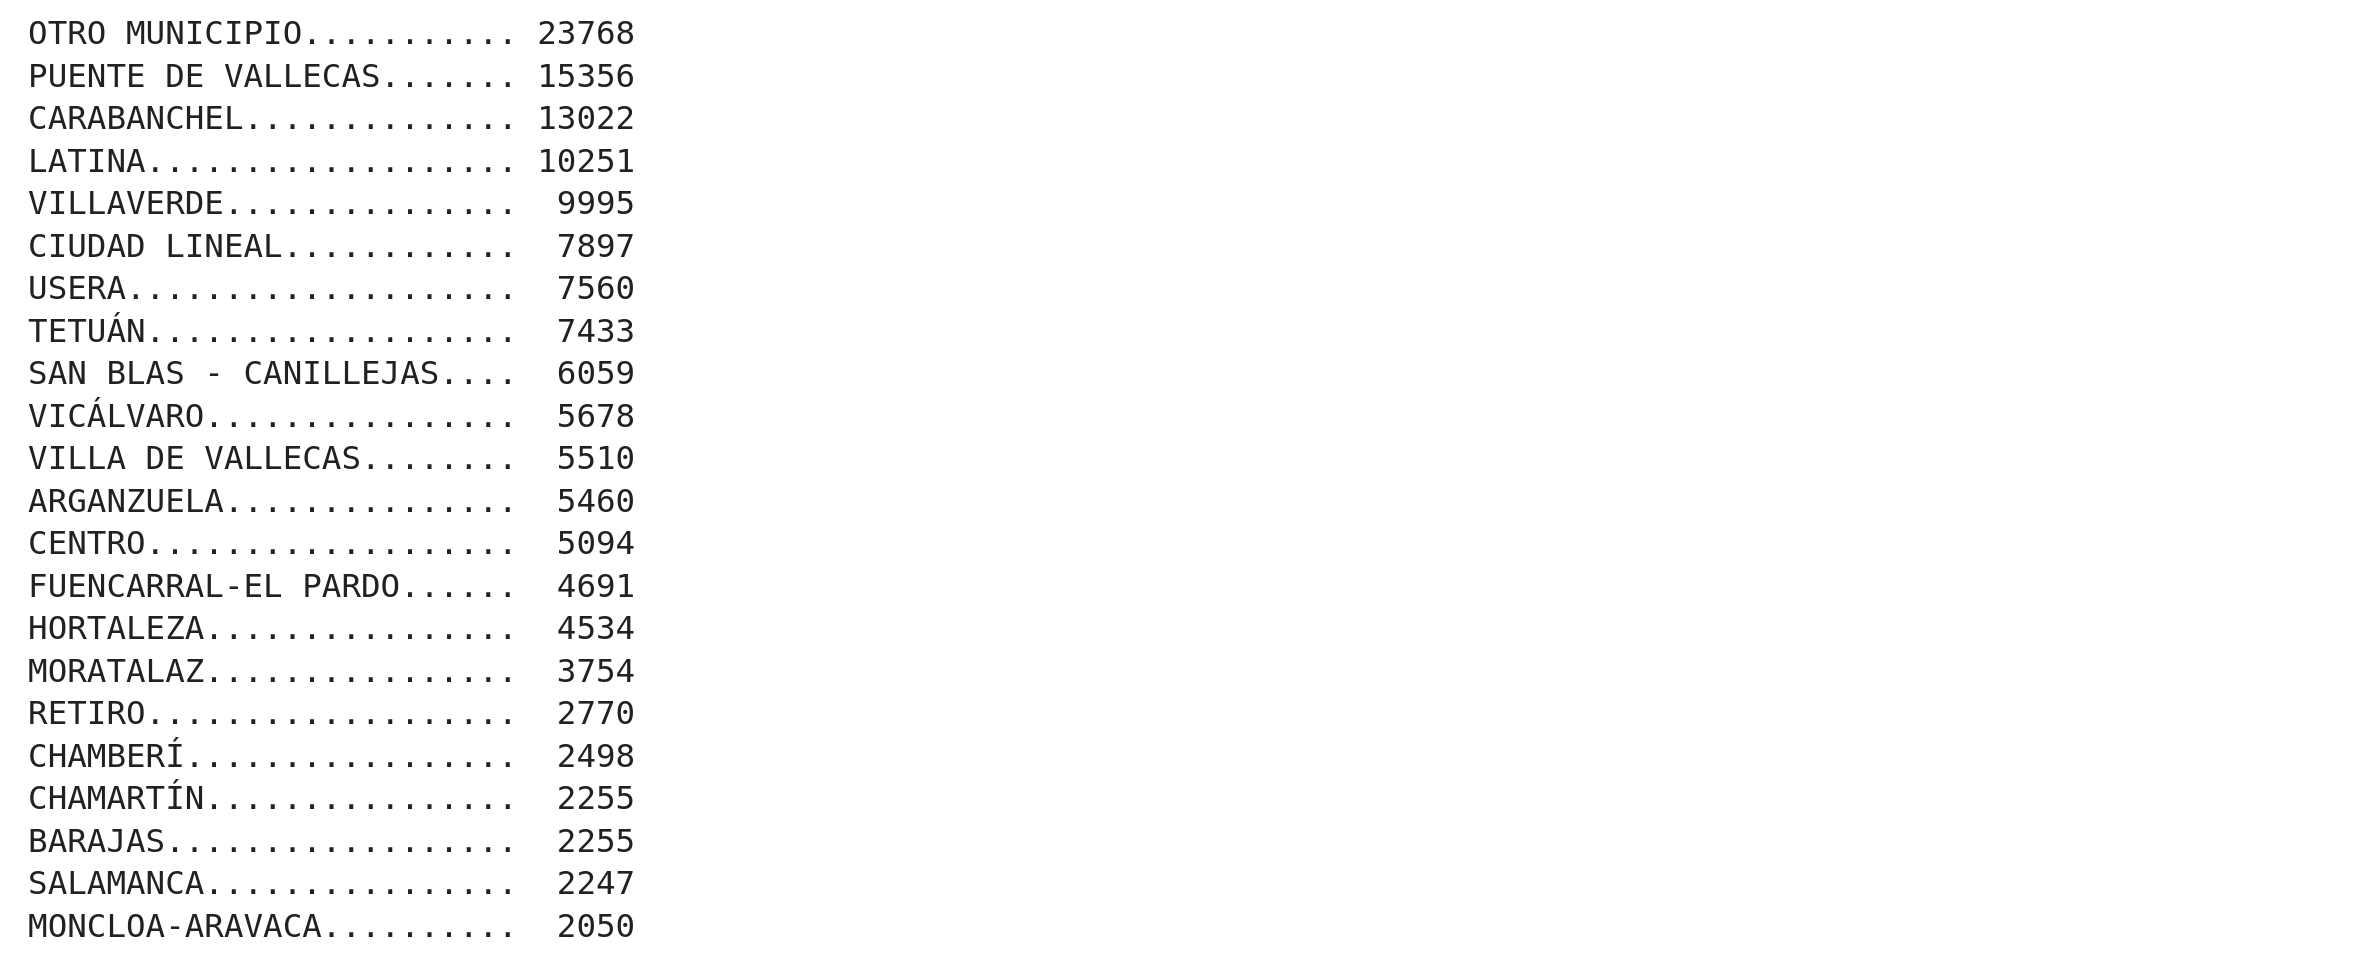


Puedes comprobar los doctests de tu función. 

In [67]:
doctest.run_docstring_examples(people_by_district, globals(), verbose=True)

Finding tests in NoName
Trying:
    people_by_district(employment_test_data)
Expecting:
    [('OTRO MUNICIPIO', 268), ('PUENTE DE VALLECAS', 141), ('CARABANCHEL', 124), ('LATINA', 123), ('VILLAVERDE', 94), ('CIUDAD LINEAL', 90), ('VILLA DE VALLECAS', 73), ('USERA', 71), ('TETUÁN', 71), ('VICÁLVARO', 54), ('FUENCARRAL-EL PARDO', 50), ('CENTRO', 48), ('ARGANZUELA', 46), ('HORTALEZA', 45), ('MORATALAZ', 41), ('SAN BLAS - CANILLEJAS', 41), ('CHAMBERÍ', 26), ('SALAMANCA', 25), ('RETIRO', 23), ('CHAMARTÍN', 21), ('MONCLOA-ARAVACA', 18), ('BARAJAS', 15)]
ok


Comprueba la calidad del docstring

In [68]:
help(people_by_district)

Help on function people_by_district in module __main__:

people_by_district(data: EmploymentData) -> list[tuple[str, int]]
    Devuelve una lista ordenada de tuplas (distrito, número de personas)
    en orden descendente por número de inscritos.

    Parameters:
    -----------
    data : EmploymentData
        Diccionario con los datos de empleo.

    Returns:
    --------
    list[tuple[str, int]]. Lista de tuplas (nombre_distrito, num_personas) ordenada de forma
        descendente por número de personas.

    Example:
    --------
    >>> people_by_district(employment_test_data)
    [('OTRO MUNICIPIO', 268), ('PUENTE DE VALLECAS', 141), ('CARABANCHEL', 124), ('LATINA', 123), ('VILLAVERDE', 94), ('CIUDAD LINEAL', 90), ('VILLA DE VALLECAS', 73), ('USERA', 71), ('TETUÁN', 71), ('VICÁLVARO', 54), ('FUENCARRAL-EL PARDO', 50), ('CENTRO', 48), ('ARGANZUELA', 46), ('HORTALEZA', 45), ('MORATALAZ', 41), ('SAN BLAS - CANILLEJAS', 41), ('CHAMBERÍ', 26), ('SALAMANCA', 25), ('RETIRO', 23), ('CHA

### Comprobación automática

In [69]:
data = load_employment('inscritos_test_sample.csv')
people_by_district(data)

[('OTRO MUNICIPIO', 268),
 ('PUENTE DE VALLECAS', 141),
 ('CARABANCHEL', 124),
 ('LATINA', 123),
 ('VILLAVERDE', 94),
 ('CIUDAD LINEAL', 90),
 ('VILLA DE VALLECAS', 73),
 ('USERA', 71),
 ('TETUÁN', 71),
 ('VICÁLVARO', 54),
 ('FUENCARRAL-EL PARDO', 50),
 ('CENTRO', 48),
 ('ARGANZUELA', 46),
 ('HORTALEZA', 45),
 ('MORATALAZ', 41),
 ('SAN BLAS - CANILLEJAS', 41),
 ('CHAMBERÍ', 26),
 ('SALAMANCA', 25),
 ('RETIRO', 23),
 ('CHAMARTÍN', 21),
 ('MONCLOA-ARAVACA', 18),
 ('BARAJAS', 15)]

In [70]:
testing.test_people_by_district(people_by_district)

people_by_district OK


In [71]:
testing.test_people_by_district_typehints(people_by_district)

people_by_district type hints OK


In [72]:
testing.test_doctests(people_by_district, globals())

doctests OK


In [73]:
testing.test_docstring(people_by_district)

docstring OK


## Función `mean_age_by_district`

Realiza una función que calcule la edad media de cada distrito. Debe devolver un diccionario, la clave es el nombre del distrito y el valor la edad media.

**NOTA** Si hay alguna fila que no tiene la edad, lo hemos indicado como que su edad es 0, no debe ser computado a la hora de calcular la media. Es como si ese dato no existiera.

In [74]:
def mean_age_by_district(data: EmploymentData) -> dict[str, float]:
    """
    Realiza una función que calcula la edad media de cada distrito. 
    Devuelve un diccionario con clave el nombre del distrito 
    y el valor, la edad media.

    Parameters:
    -----------
    data : EmploymentData. Diccionario con los datos de empleo.

    Returns:
    --------
    dict[str, float]. Diccionario con el nombre del distrito como clave y la 
        edad media como valor.

    Example:
    --------
    >>> data = {'DISTRITO_DESC': ['LATINA', 'LATINA', 'PUENTE DE VALLECAS'], 'EDAD': [25, 30, 0]}
    >>> mean_age_by_district(data)
    {'LATINA': 27.5, 'PUENTE DE VALLECAS': 0.0}
    """
    # Diccionario para almacenar las edades por distrito
    edades_por_distrito = {}
    
    # 1. Iteramos sobre los datos para agrupar edades por distrito
    for i in range(len(data['DISTRITO_DESC'])):
        distrito = data['DISTRITO_DESC'][i].strip()
        edad = data['EDAD'][i]
        
        # Solo añadimos edades válidas (no 0)
        if edad != 0:
            if distrito not in edades_por_distrito:
                edades_por_distrito[distrito] = []
            edades_por_distrito[distrito].append(edad)
    
    # 2. Calculamos la media de edades por distrito
    resultado: dict[str, float] = {}
    for distrito in data['DISTRITO_DESC']:
        if distrito in edades_por_distrito:  # Si hay edades válidas
            resultado[distrito] = sum(edades_por_distrito[distrito]) / len(edades_por_distrito[distrito])
        else:  # Si no hay edades válidas (todas eran 0)
            resultado[distrito] = 0.0
    
    return resultado

In [75]:
# Espacio para pruebas
data = {'DISTRITO_DESC': ['LATINA', 'LATINA', 'PUENTE DE VALLECAS'], 'EDAD': [25, 30, 0]}
mean_age_by_district(data)

{'LATINA': 27.5, 'PUENTE DE VALLECAS': 0.0}

### Autocomprobación

In [76]:
def check_mean_age_by_district():
    global employment_data
    for district, mage in mean_age_by_district(employment_test_data).items():
        print(f'{district:.<25s}{mage:>6.2f}')
check_mean_age_by_district()

OTRO MUNICIPIO........... 37.83
MORATALAZ................ 38.20
PUENTE DE VALLECAS....... 40.36
USERA.................... 38.51
CIUDAD LINEAL............ 40.07
CARABANCHEL.............. 38.39
HORTALEZA................ 41.00
VILLAVERDE............... 40.77
LATINA................... 42.11
ARGANZUELA............... 38.74
VILLA DE VALLECAS........ 42.77
CENTRO................... 39.96
MONCLOA-ARAVACA.......... 42.78
RETIRO................... 38.26
VICÁLVARO................ 38.30
FUENCARRAL-EL PARDO...... 39.30
CHAMBERÍ................. 46.00
CHAMARTÍN................ 40.33
BARAJAS.................. 42.93
SAN BLAS - CANILLEJAS.... 36.46
TETUÁN................... 37.48
SALAMANCA................ 43.44


Salida esperada:

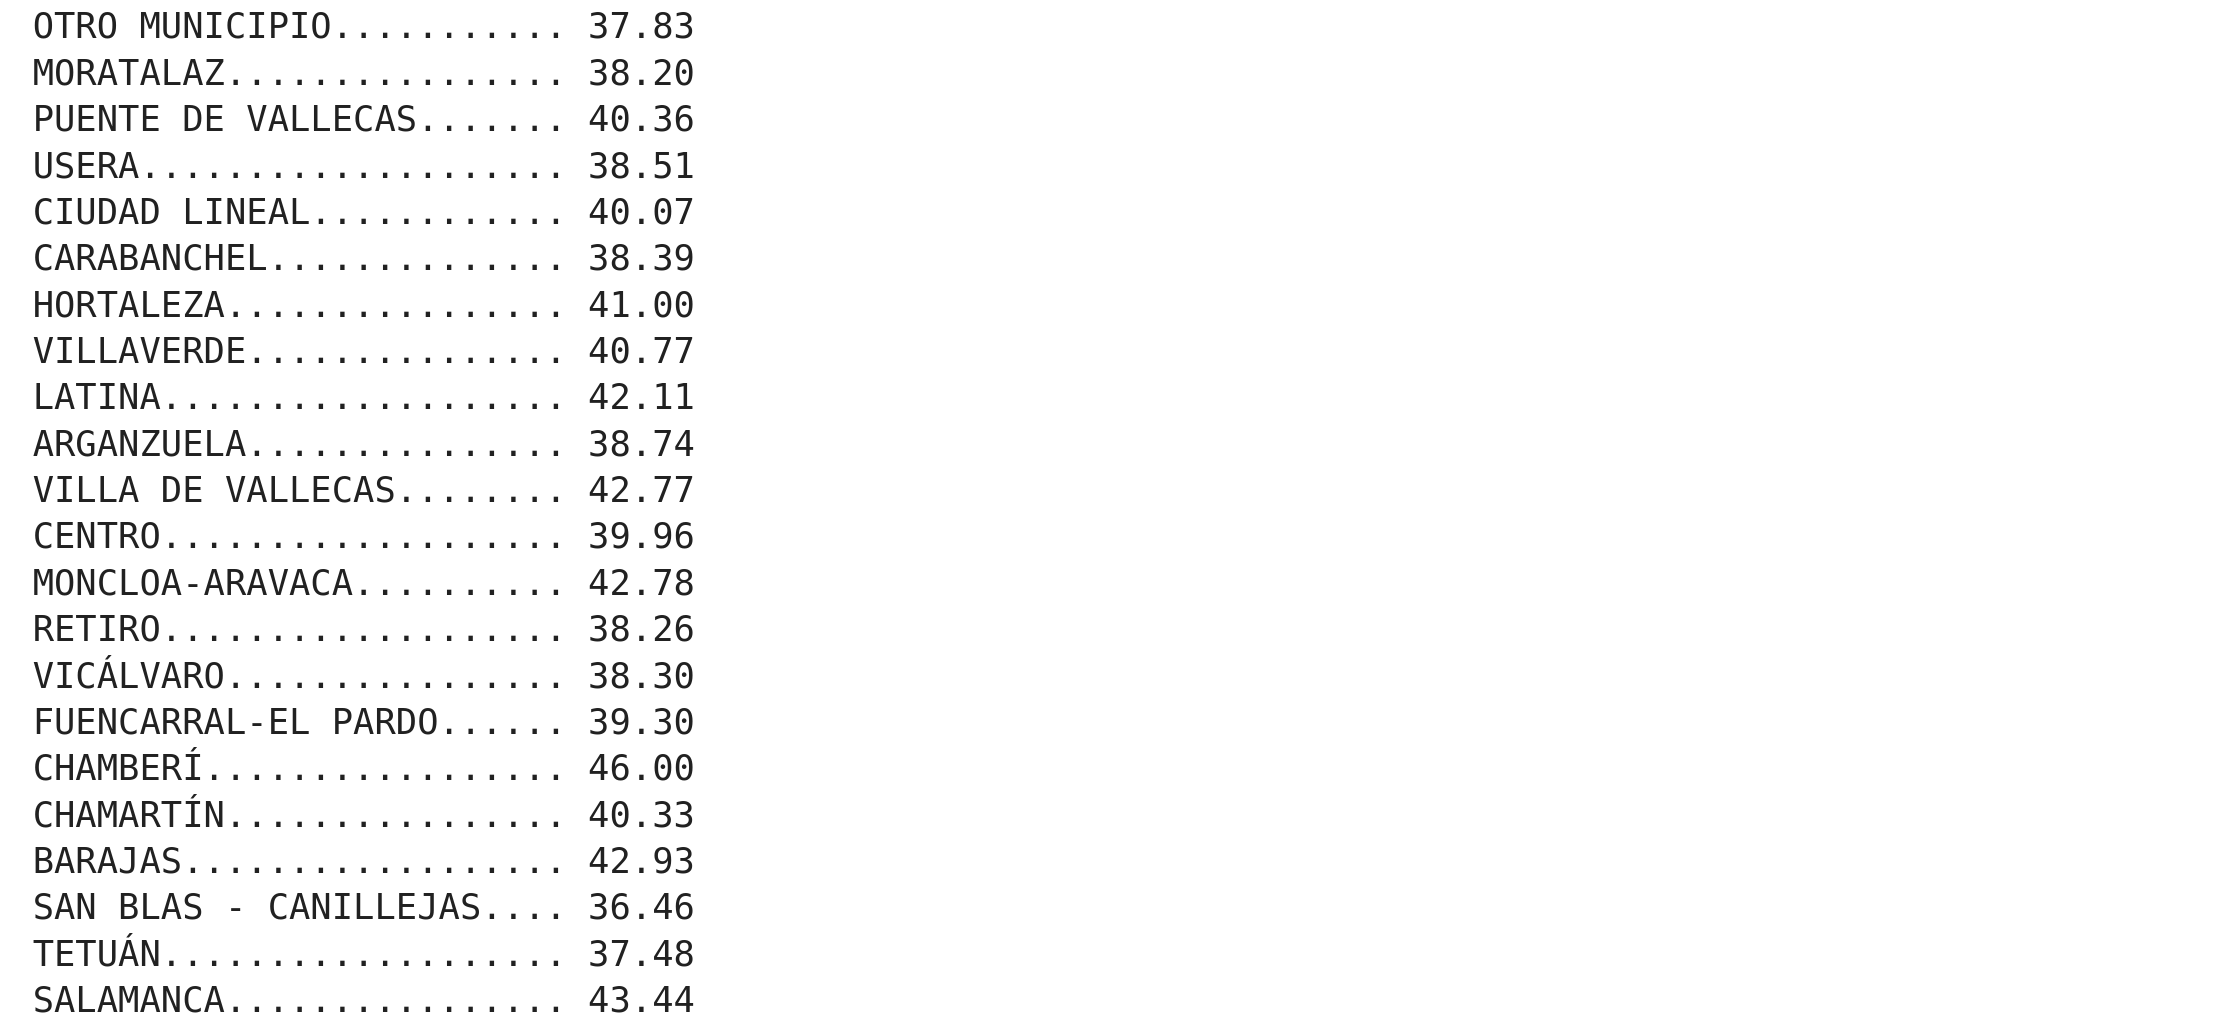

Comprueba la calidad del docstring

In [77]:
help(mean_age_by_district)

Help on function mean_age_by_district in module __main__:

mean_age_by_district(data: EmploymentData) -> dict[str, float]
    Realiza una función que calcula la edad media de cada distrito.
    Devuelve un diccionario con clave el nombre del distrito
    y el valor, la edad media.

    Parameters:
    -----------
    data : EmploymentData. Diccionario con los datos de empleo.

    Returns:
    --------
    dict[str, float]. Diccionario con el nombre del distrito como clave y la
        edad media como valor.

    Example:
    --------
    >>> data = {'DISTRITO_DESC': ['LATINA', 'LATINA', 'PUENTE DE VALLECAS'], 'EDAD': [25, 30, 0]}
    >>> mean_age_by_district(data)
    {'LATINA': 27.5, 'PUENTE DE VALLECAS': 0.0}



Puedes comprobar los doctests de tu función. 

In [78]:
doctest.run_docstring_examples(mean_age_by_district, globals(), verbose=True)

Finding tests in NoName
Trying:
    data = {'DISTRITO_DESC': ['LATINA', 'LATINA', 'PUENTE DE VALLECAS'], 'EDAD': [25, 30, 0]}
Expecting nothing
ok
Trying:
    mean_age_by_district(data)
Expecting:
    {'LATINA': 27.5, 'PUENTE DE VALLECAS': 0.0}
ok


Comprueba la calidad del docstring

### Comprobación automática

In [79]:
testing.test_mean_age_by_district(mean_age_by_district)

mean_age_by_district OK


In [80]:
mean_age_by_district.__annotations__

{'data': __main__.EmploymentData, 'return': dict[str, float]}

In [81]:
testing.test_mean_age_by_district_typehints(mean_age_by_district)

mean_age_by_district type hints OK


In [82]:
testing.test_docstring(mean_age_by_district)

docstring OK


In [83]:
testing.test_doctests(mean_age_by_district, globals())

doctests OK


# Ejercicios con `numpy`

En los ejercicios siguientes se practicará la librería `numpy`, que se importará con el nombre `np` como de costumbre. 

## Función `year_month_data`

A continuación constuiremos a partir de un diccionario de tipo `EmploymentData`, un array de `numpy` de forma que haya una fila por cada año y una columna por cada mes. En cada casilla habrá el número de solicitudes del año y mes correspondiente.

La fila 0 se corresponderá al mínimo de los años que aparezca, y habrá una fila por cada uno de los años hasta el máximo de los años posibles. Si en algún año no hay inscripciones deberá aparecer una fila rellena con ceros. El mes 0 se corresponde con enero y el mes 11 con diciembre.


In [85]:
def  year_month_data( data : EmploymentData ) -> tuple[np.ndarray, int] :
    """
    Construye un array de numpy con el número de inscripciones por año y mes.

    Las filas representan años (desde el mínimo al máximo encontrado) y las
    columnas representan meses (0=enero, 11=diciembre). Si un año no tiene
    inscripciones, aparece como fila de ceros.

    Parametros:
    -----------
    data : EmploymentData
        Diccionario con los datos de empleo.

    Returns:
    --------
    np.ndarray : Array de shape (num_años, 12) con el número de inscripciones
        por año y mes.

    Example:
    --------
    >>> import datetime
    >>> data = {'FECHA_INSCRIPCION': [datetime.datetime(2017, 1, 1), datetime.datetime(2018, 1, 1)]}
    >>> res, start_year = year_month_data(data)
    >>> start_year
    2017
    >>> res
    array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
           [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
    """

    fechas = data['FECHA_INSCRIPCION']
    
    if not fechas:
        return np.array([[]])

    # 1. Extraemos años y meses de las fechas
    years = [f.year for f in fechas]
    months = [f.month for f in fechas]
    
    min_year = min(years)
    max_year = max(years)
    num_years = max_year - min_year + 1
    
    # 2. Creamos la matriz vacía (filas para años y 12 columnas para meses)
    # Iniciamos en cero para que los años sin datos ya estén "rellenos"
    res_matrix = np.zeros((num_years, 12), dtype=int)
    
    # 3. Contabilizamos las inscripciones
    # Iteramos por cada fecha y sumamos 1 en la posición correspondiente
    for y, m in zip(years, months):
        row = y - min_year
        col = m - 1  # datetime.month va de 1 (enero) a 12 (diciembre)
        res_matrix[row, col] += 1
        
    return res_matrix, min_year

### Autocomprobación

In [86]:
def check_month_data():
    global employment_data
    ym_data, ini_y = year_month_data(employment_data)
    print(f"Año inicial: {ini_y}")
    print(ym_data)

check_month_data()

Año inicial: 2017
[[1177 1508 1632 1204 1256 1434 1143  915 1233 1712 1753  978]
 [1258 1365 1398 1321 1371 1155  947  749 1124 1340 1437 1418]
 [1259 1651 1804 1537 1336 1154 1076  784 1341 1911 1586 1290]
 [1185 1511  827  769  822 1370  880  814 1586 2011 1716 1619]
 [ 861 1857 1580 1982 1799 1638  902  727 1326 1121  956 1396]
 [ 804 2129 2257 1677 2014 1727 1338 1511 1711 1939 2292 1800]
 [1665 1699 1860 1219 1606 1448 1469  880 1166 1557 1807 1417]
 [1479 1982 2034 2330 2363 1989 1630  847 1065 1753 1353  861]
 [ 796 1084 1240 1397 1448 5742  828  112    0    0    0    0]]


Salida esperada:

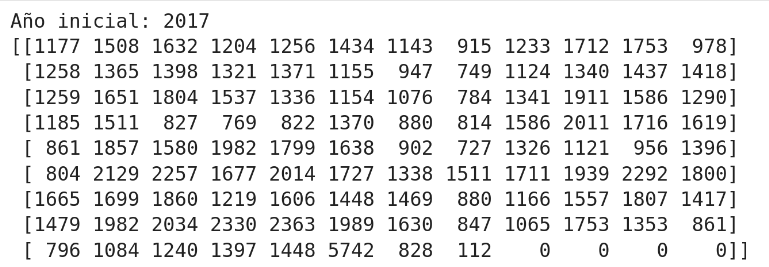

Comprueba tus doctests

In [87]:
doctest.run_docstring_examples(year_month_data, globals(), verbose=True)

Finding tests in NoName
Trying:
    import datetime
Expecting nothing
ok
Trying:
    data = {'FECHA_INSCRIPCION': [datetime.datetime(2017, 1, 1), datetime.datetime(2018, 1, 1)]}
Expecting nothing
ok
Trying:
    res, start_year = year_month_data(data)
Expecting nothing
ok
Trying:
    start_year
Expecting:
    2017
ok
Trying:
    res
Expecting:
    array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
           [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
ok


Comprueba tu docstring

In [88]:
help(year_month_data)

Help on function year_month_data in module __main__:

year_month_data(data: EmploymentData) -> tuple[np.ndarray, int]
    Construye un array de numpy con el número de inscripciones por año y mes.

    Las filas representan años (desde el mínimo al máximo encontrado) y las
    columnas representan meses (0=enero, 11=diciembre). Si un año no tiene
    inscripciones, aparece como fila de ceros.

    Parametros:
    -----------
    data : EmploymentData
        Diccionario con los datos de empleo.

    Returns:
    --------
    np.ndarray : Array de shape (num_años, 12) con el número de inscripciones
        por año y mes.

    Example:
    --------
    >>> import datetime
    >>> data = {'FECHA_INSCRIPCION': [datetime.datetime(2017, 1, 1), datetime.datetime(2018, 1, 1)]}
    >>> res, start_year = year_month_data(data)
    >>> start_year
    2017
    >>> res
    array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
           [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])



### Corrección automática

In [89]:
testing.test_year_month_data(year_month_data)

year_month_data OK


In [90]:
testing.test_year_month_data_typehints(year_month_data)

year_month_data type hints OK


In [91]:
testing.test_docstring(year_month_data)

docstring OK


In [92]:
testing.test_doctests(year_month_data, globals())

doctests OK


Puedes comprobar los doctests de tu función. Si son correctos no debería salir nada aquí.

## Función `sum_by_month_year`

**Importante**: En esta función y en el resto de ejercicios de `numpy` **NO** se deben usar un bucles (`while`, `for`), solamente funciones de `numpy`.

En esta función se parte de una matriz como la obtenida en el ejercicio anterior. La función devuelve 2 arrays de `numpy`: el primero es la suma de los datos por meses (un array con 12 posiciones); el segundo es la suma por años deberá haber un elemento por cada año.


In [93]:
def sum_by_month_year(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Calcula la suma de inscripciones por meses y por años sin usar bucles.

    Parametros:
    -----------
    matrix : np.ndarray
        Matriz de forma (num_años, 12).

    Returns:
    --------
    (np.ndarray, np.ndarray)
        - Array de 12 elementos (suma por meses).
        - Array de N elementos (suma por años).

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    >>> sum_by_month_year(mat)
    (array([1, 1, 0, 0]), array([1, 1]))
    """    

    # 1. Sumamos todas las filas para cada columna (total por meses)
    sum_months = np.sum(matrix, axis=0)
    
    # 2. Sumamos todas las columnas para cada fila (total por años)
    sum_years = np.sum(matrix, axis=1)
    
    return sum_months, sum_years


In [94]:
# Casilla para pruebas


### Autocomprobación

In [95]:
def check_sum_by_month_year():
    ym_data2 = \
      np.array([[ 9, 10,  9, 10,  3, 20, 17, 10,  7,  7, 23, 15],\
                [12, 17, 15, 11, 11, 13, 15,  4, 12, 24, 14, 17],\
                [17, 11, 21, 13, 19, 13, 16, 12, 10, 16, 15, 17]])
    by_month, by_year = sum_by_month_year(ym_data2)
    print(f"Por meses-1: {by_month}")
    print(f"Por años-1: {by_year}")

    ym_data, ini_y = year_month_data(employment_data)
    by_month, by_year = sum_by_month_year(ym_data)
    print(f"Por meses-1: {by_month}")
    print(f"Por años-1: {by_year}")


check_sum_by_month_year()


Por meses-1: [38 38 45 34 33 46 48 26 29 47 52 49]
Por años-1: [140 165 180]
Por meses-1: [10484 14786 14632 13436 14015 17657 10213  7339 10552 13344 12900 10779]
Por años-1: [15945 14883 16729 15110 16145 21199 17793 19686 12647]


Salida esperada:

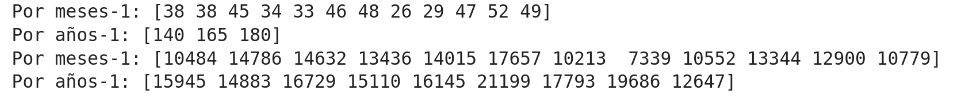

Comprobación de doctests

In [96]:
doctest.run_docstring_examples(sum_by_month_year, globals(), verbose=True)

Finding tests in NoName
Trying:
    import numpy as np
Expecting nothing
ok
Trying:
    mat = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
Expecting nothing
ok
Trying:
    sum_by_month_year(mat)
Expecting:
    (array([1, 1, 0, 0]), array([1, 1]))
ok


Comprobación de docstring

In [97]:
help(sum_by_month_year)

Help on function sum_by_month_year in module __main__:

sum_by_month_year(matrix: np.ndarray) -> tuple[np.ndarray, np.ndarray]
    Calcula la suma de inscripciones por meses y por años sin usar bucles.

    Parametros:
    -----------
    matrix : np.ndarray
        Matriz de forma (num_años, 12).

    Returns:
    --------
    (np.ndarray, np.ndarray)
        - Array de 12 elementos (suma por meses).
        - Array de N elementos (suma por años).

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 0, 0, 0], [0, 1, 0, 0]])
    >>> sum_by_month_year(mat)
    (array([1, 1, 0, 0]), array([1, 1]))



### Comprobaciones automáticas

In [98]:
testing.test_sum_by_month_year(sum_by_month_year)

data: [[ 9 10  9 10  3 20 17 10  7  7 23 15]
 [12 17 15 11 11 13 15  4 12 24 14 17]
 [17 11 21 13 19 13 16 12 10 16 15 17]]
sum_by_month_year OK


In [99]:
testing.test_sum_by_month_year_typehints(sum_by_month_year)

sum_by_month_year type hints OK


In [100]:
testing.test_doctests(sum_by_month_year, globals())

doctests OK


In [101]:
testing.test_docstring(sum_by_month_year)

docstring OK


## Función `max_requests`

Esta función debe tomar un array de `numpy` como en los casos anteriores y debe devolver el año, mes y valor máximo entre todas las entradas del array. Para saber el año debemos saber qué año se corresponde con la fila 0. Será un parámetro de la función. La función devolverá los valores por este orden: año, mes, valor; y como tipos básicos de python: `int`, `str` e `int` respectivamente.

In [102]:
def max_requests( matrix: np.ndarray, year: int) -> tuple[int, str, int]:
    """
    Dado un año, devuelve el mes con más inscripciones, el número de inscripciones y el año.

    Parametros:
    -----------
    matrix : np.ndarray
        Matriz de forma (num_años, 12) con el número de inscripciones por año y mes.
    year : int
        Año para el que se desea conocer el mes con más inscripciones.

    Returns:
    --------
    (int, str, int)
        - Año consultado.
        - Nombre del mes con más inscripciones.
        - Número de inscripciones del mes con más inscripciones.

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 2, 3], [4, 5, 6]])
    >>> max_requests(mat, 2020)
    (2021, 'mar', 6)
    """
    # Mapeo de índices de columna a meses
    meses = {0: 'ene', 1: 'feb', 2: 'mar', 3: 'abr', 4: 'may', 5: 'jun',
             6: 'jul', 7: 'ago', 8: 'sep', 9: 'oct', 10: 'nov', 11: 'dic'}

    # 1. Encontramos el índice del máximo absoluto como si la matriz fuera una lista plana
    idx = np.argmax(matrix)

    # 2. Convertimos ese índice plano en coordenadas (fila, columna)
    # fila = año, columna = mes
    row_idx, col_idx = np.unravel_index(idx, matrix.shape)

    # 3. Obtenemos los valores reales
    max_inscripciones = matrix[row_idx, col_idx]
    year_of_max = year + row_idx
    month_name = meses[col_idx]

    return int(year_of_max), str(month_name), int(max_inscripciones)


In [103]:
# Casilla para pruebas


### Autocomprobación

In [104]:
def check_max_requests():
    global employment_data
    
    ym_data2 = \
      np.array([[ 9, 10,  9, 10,  3, 20, 17, 10,  7,  7, 23, 15],\
                [12, 17, 15, 11, 11, 13, 15,  4, 12, 24, 14, 17],\
                [17, 11, 21, 13, 19, 13, 16, 12, 10, 16, 15, 17]])
    year, month, val = max_requests(ym_data2, 2020)
    print(f"Año-1: {year}")
    print(f"Mes-1: {month}")
    print(f"Valor-1: {val}")
    print("\n===================\n")
    ym_data, ini_y = year_month_data(employment_data)
    year, month, val = max_requests(ym_data, 2017)
    print(f"Año-2: {year}")
    print(f"Mes-2: {month}")
    print(f"Valor-2: {val}")

check_max_requests()

Año-1: 2021
Mes-1: oct
Valor-1: 24


Año-2: 2025
Mes-2: jun
Valor-2: 5742


Salida esperada:

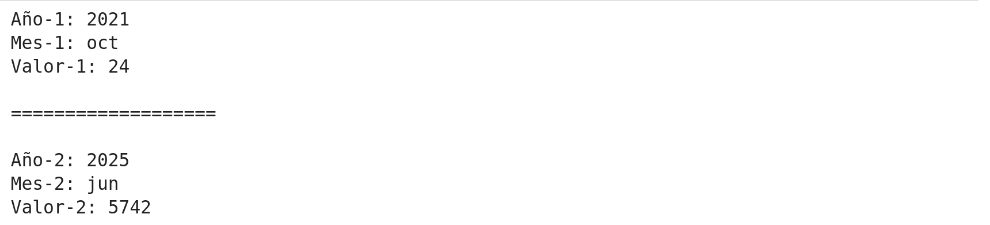

Comprobacion de docstring

In [105]:
help(max_requests)

Help on function max_requests in module __main__:

max_requests(matrix: np.ndarray, year: int) -> tuple[int, str, int]
    Dado un año, devuelve el mes con más inscripciones, el número de inscripciones y el año.

    Parametros:
    -----------
    matrix : np.ndarray
        Matriz de forma (num_años, 12) con el número de inscripciones por año y mes.
    year : int
        Año para el que se desea conocer el mes con más inscripciones.

    Returns:
    --------
    (int, str, int)
        - Año consultado.
        - Nombre del mes con más inscripciones.
        - Número de inscripciones del mes con más inscripciones.

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 2, 3], [4, 5, 6]])
    >>> max_requests(mat, 2020)
    (2021, 'mar', 6)



Comprobación de doctests

In [106]:
doctest.run_docstring_examples(max_requests, globals(), verbose=True)

Finding tests in NoName
Trying:
    import numpy as np
Expecting nothing
ok
Trying:
    mat = np.array([[1, 2, 3], [4, 5, 6]])
Expecting nothing
ok
Trying:
    max_requests(mat, 2020)
Expecting:
    (2021, 'mar', 6)
ok


### Comprobación automática

In [107]:
testing.test_max_requests(max_requests)

data: [[ 9 10  9 10  3 20 17 10  7  7 23 15]
 [12 17 15 11 11 13 15  4 12 24 14 17]
 [17 11 21 13 19 13 16 12 10 16 15 17]]
max_requests OK


In [108]:
testing.test_max_requests_typehints(max_requests)

max_requests type hints OK


In [109]:
testing.test_docstring(max_requests)

docstring OK


In [110]:
testing.test_doctests(max_requests, globals())

doctests OK


## función `by_quarters`

La función `by_quarters`, a partir de una matriz como en los casos anteriores, devuelve una matriz similar pero con los datos por trimestres. Es decir la matriz tendrá una fila por año, con 
cuatro elementos en cada fila, uno por cada trimestre.

In [ ]:
def by_quarters(matrix: np.ndarray) -> np.ndarray:
    """
    Agrupa las inscripciones por trimestres.

    Parametros:
    -----------
    matrix : np.ndarray. Matriz de forma (num_años, 12) con el número de inscripciones por año y mes.

    Returns:
    --------
    np.ndarray : Matriz de forma (num_años, 4) con el número de inscripciones por año y trimestre.

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0], [5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0]])
    >>> by_quarters(mat)
    array([[ 6,  4,  0,  0],
           [18,  8,  0,  0]])
    """
    
    # 1. Sumamos los meses correspondientes a cada trimestre
    q1 = matrix[:, :3].sum(axis=1)   # Enero, Febrero, Marzo
    q2 = matrix[:, 3:6].sum(axis=1)  # Abril, Mayo, Junio
    q3 = matrix[:, 6:9].sum(axis=1)  # Julio, Agosto, Septiembre
    q4 = matrix[:, 9:12].sum(axis=1) # Octubre, Noviembre, Diciembre
    
    # 2. Combinamos los resultados en una nueva matriz
    return np.column_stack((q1, q2, q3, q4))

In [112]:
mat = np.array([[1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0], [5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0]])
by_quarters(mat)

array([[ 6,  4,  0,  0],
       [18,  8,  0,  0]])

In [113]:
def check_by_quarters():
    global employment_data

    ym_data2 = \
      np.array([[ 9, 10,  9, 10,  3, 20, 17, 10,  7,  7, 23, 15],\
                [12, 17, 15, 11, 11, 13, 15,  4, 12, 24, 14, 17],\
                [17, 11, 21, 13, 19, 13, 16, 12, 10, 16, 15, 17]])
    quarters = by_quarters(ym_data2)
    print(f"Triemestres-1:\n {quarters}")
    print("\n===================\n")
    ym_data, ini_y = year_month_data(employment_data)
    quarters = by_quarters(ym_data)
    print(f"Triemestres-2:\n {quarters}")

check_by_quarters()

Triemestres-1:
 [[28 33 34 45]
 [44 35 31 55]
 [49 45 38 48]]


Triemestres-2:
 [[4317 3894 3291 4443]
 [4021 3847 2820 4195]
 [4714 4027 3201 4787]
 [3523 2961 3280 5346]
 [4298 5419 2955 3473]
 [5190 5418 4560 6031]
 [5224 4273 3515 4781]
 [5495 6682 3542 3967]
 [3120 8587  940    0]]


Salida esperada:

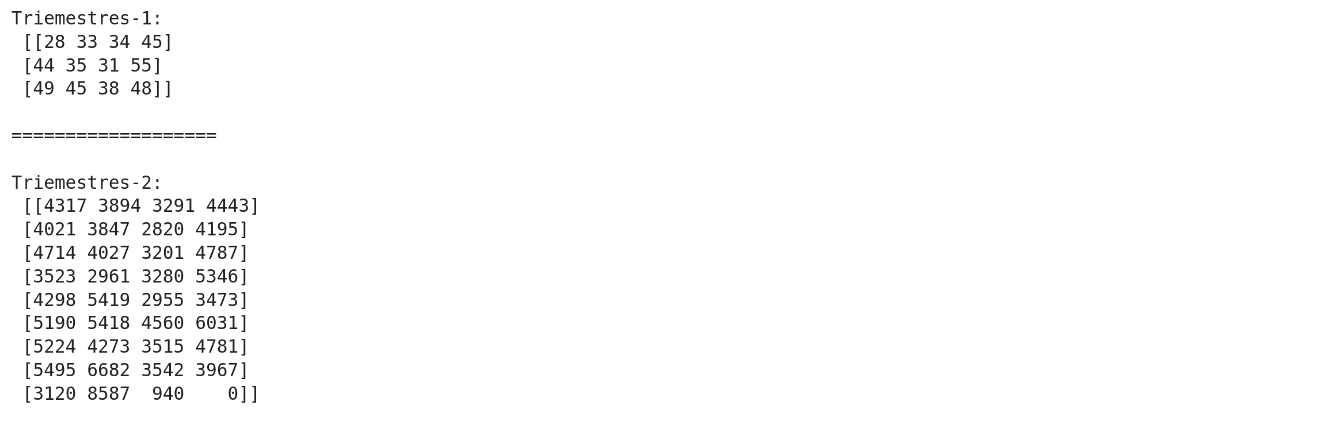

Comprobación de docstring

In [114]:
help(by_quarters)

Help on function by_quarters in module __main__:

by_quarters(matrix: np.ndarray) -> np.ndarray
    Agrupa las inscripciones por trimestres.

    Parametros:
    -----------
    matrix : np.ndarray
        Matriz de forma (num_años, 12) con el número de inscripciones por año y mes.

    Returns:
    --------
    np.ndarray : Matriz de forma (num_años, 4) con el número de inscripciones por año y trimestre.

    Example:
    --------
    >>> import numpy as np
    >>> mat = np.array([[1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0], [5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0]])
    >>> by_quarters(mat)
    array([[ 6,  4,  0,  0],
           [18,  8,  0,  0]])



Comprobación de doctests

In [115]:
doctest.run_docstring_examples(by_quarters, globals(), verbose=True)

Finding tests in NoName
Trying:
    import numpy as np
Expecting nothing
ok
Trying:
    mat = np.array([[1, 2, 3, 4, 0, 0, 0, 0, 0, 0, 0, 0], [5, 6, 7, 8, 0, 0, 0, 0, 0, 0, 0, 0]])
Expecting nothing
ok
Trying:
    by_quarters(mat)
Expecting:
    array([[ 6,  4,  0,  0],
           [18,  8,  0,  0]])
ok


### Corrección automática

In [116]:
testing.test_by_quarters(by_quarters)

data: [[ 9 10  9 10  3 20 17 10  7  7 23 15]
 [12 17 15 11 11 13 15  4 12 24 14 17]
 [17 11 21 13 19 13 16 12 10 16 15 17]]
by_quarters OK


In [117]:
testing.test_by_quarters_typehints(by_quarters)

by_quarters type hints OK


In [118]:
testing.test_docstring(by_quarters)

docstring OK


In [119]:
testing.test_doctests(by_quarters, globals())

doctests OK
